## Installing Packages

In [1]:
# Install required packages (run once if needed)
required_packages <- c(
  "readxl", "dplyr", "ggplot2", "lubridate", "tidyr", "cluster",
  "factoextra", "caret", "rpart", "rpart.plot", "nnet", "randomForest", "forecast",
  "tseries", "pROC", "scales", "janitor", "forcats", "Metrics"
)

new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(new_packages) > 0) install.packages(new_packages)

## Loading Libraries

In [2]:
library(readxl)
library(dplyr)
library(ggplot2)
library(lubridate)
library(tidyr)
library(cluster)
library(factoextra)
library(caret)
library(rpart)
library(rpart.plot)
library(nnet)
library(randomForest)
library(forecast)
library(tseries)
library(pROC)
library(scales)
library(janitor)
library(forcats)
library(Metrics)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

Loading required package: lattice

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:

## Executive Summary

This notebook applies data mining and machine learning techniques to the UCI Online Retail dataset (541,909 transactions, December 2010 to December 2011) to support customer retention analysis and revenue forecasting.

**Data preparation:** After removing records with missing customer identifiers, negative quantities, and zero-price entries, 397,884 clean transactions across 4,338 unique customers were retained. Transaction-level data was aggregated into customer-level behavioural features including Recency, Frequency, TotalSpent, average order value, average items per order, product diversity, and purchase intensity. Selected skewed variables were log-transformed and standardised before modelling.

**Clustering:** K-means clustering with k = 3 identified three distinct customer groups: high-value loyal customers, occasional buyers, and at-risk customers. PCA and hierarchical clustering were used to validate and visualise the segmentation.

**Classification:** Churn prediction was evaluated using a Decision Tree, Neural Network, and Random Forest. The Neural Network achieved the strongest overall discrimination by AUC, while threshold tuning improved recall for operational churn capture. The Decision Tree remained the most interpretable recall-oriented model.

**Time series:** Monthly revenue showed a strong upward trend through late 2011, peaking in November. ARIMA, ETS, and Seasonal Naive forecasts were compared on a holdout period, with ARIMA selected as a directional forecasting model while acknowledging the limits of the short series.


---
## Research Hypothesis

Based on the exploratory analysis of the retail data, three hypotheses are proposed:

**H1 – Customer Segmentation:** Customers will naturally group into three behaviorally distinct tiers — *VIPs* (high spend, high frequency, low recency), *Occasional* (moderate scores), and *At-Risk* (high recency, low spend, low frequency). This is supported by the visible spread in recency values, with a substantial portion of customers not having purchased in over 90 days.

**H2 – Churn Prediction:** The Neural Network will achieve a higher AUC than the Decision Tree at predicting churn, because the relationship between purchase behavior and churn likelihood is complex and non-linear. However, threshold tuning may be needed for both models to balance precision and recall appropriately.

**H3 – Seasonality:** Revenue will show an upward trend toward the end of the year driven by holiday shopping. The time series model will capture this trend and use it to forecast future transaction volumes. Note that December 2011 data is truncated to 9 days and will not reflect a full month's revenue — November 2011 is expected to be the true seasonal peak in this dataset.

---


## Loading the Dataset

In [3]:
# Helper: load dataset automatically from common filenames/extensions
load_retail_data <- function() {
  candidates <- c(
    "dataset.xlsx", "Online Retail.xlsx", "Online Retail.xls", "online_retail.xlsx",
    "online_retail.csv", "Online Retail.csv", "data.xlsx", "data.csv"
  )
  
  existing <- candidates[file.exists(candidates)]

  if (length(existing) == 0) {
    stop("No dataset file found. Please place the retail dataset in the same folder as this notebook with a name like 'dataset.xlsx' or 'Online Retail.xlsx'.")
  }

  file_path <- existing[1]
  message("Loading file: ", file_path)

  if (grepl("\\.csv$", file_path, ignore.case = TRUE)) {
    df <- read.csv(file_path, stringsAsFactors = FALSE)
  } else {
    df <- read_excel(file_path)
  }

  names(df) <- make_clean_names(names(df))

  # Standardize expected column names if needed
  rename_map <- c(
    invoice_no   = "invoice_no",
    invoiceno    = "invoice_no",
    stock_code   = "stock_code",
    stockcode    = "stock_code",
    description  = "description",
    quantity     = "quantity",
    invoice_date = "invoice_date",
    invoicedate  = "invoice_date",
    unit_price   = "unit_price",
    unitprice    = "unit_price",
    customer_id  = "customer_id",
    customerid   = "customer_id",
    country      = "country"
  )

  names(df) <- ifelse(names(df) %in% names(rename_map),
                      rename_map[names(df)],
                      names(df))
  
  return(df)
}

df <- load_retail_data()

# View first rows
head(df)

# Check structure
str(df)

# Check summary
summary(df)

Loading file: dataset.xlsx



invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ invoice_no  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ stock_code  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ description : chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ quantity    : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ invoice_date: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ unit_price  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ customer_id : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ country     : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


  invoice_no         stock_code        description           quantity         
 Length:541909      Length:541909      Length:541909      Min.   :-80995.000  
 Class :character   Class :character   Class :character   1st Qu.:     1.000  
 Mode  :character   Mode  :character   Mode  :character   Median :     3.000  
                                                          Mean   :     9.552  
                                                          3rd Qu.:    10.000  
                                                          Max.   : 80995.000  
                                                                              
  invoice_date                   unit_price          customer_id    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:

## Data Preprocessing

### Purpose of preprocessing

The raw Online Retail dataset contains:
- missing customer identifiers (CustomerID),
- refund/return records (negative Quantity),
- potentially invalid pricing values.

These issues can distort customer-level metrics such as total spending and purchase frequency.  
Therefore, we clean the dataset and create a transaction monetary value feature (`LineTotal`) that will be used later to engineer customer features (Recency, Frequency, Monetary) and create the churn label (`IsChurned`).

In [4]:
# Create a working copy
df_clean <- df

# Convert InvoiceDate to datetime
if (!inherits(df_clean$invoice_date, c("POSIXct", "POSIXt", "Date"))) {
  df_clean <- df_clean %>%
    mutate(invoice_date = parse_date_time(invoice_date,
                                          orders = c("Ymd HMS", "Ymd HM", "mdY HM", "dmY HM", "Y-m-d H:M:S")))
}

# Quick checks before cleaning
print('Dimensions:')
dim(df_clean)
print('Null values:')
colSums(is.na(df_clean))
print('Date range:')
range(df_clean$invoice_date, na.rm = TRUE)

[1] "Dimensions:"


[1] 541909      8

[1] "Null values:"


invoice_no   stock_code  description     quantity invoice_date   unit_price 
           0            0         1454            0            0            0 
 customer_id      country 
      135080            0

[1] "Date range:"


[1] "2010-12-01 08:26:00 UTC" "2011-12-09 12:50:00 UTC"

### Cleaning rules applied

The dataset is cleaned using the following rules:

1. Remove rows with missing `CustomerID` (cannot build customer-level customer features without ID).
2. Remove rows where `Quantity <= 0` (these represent refunds/returns or corrections rather than purchases).
3. Remove rows where `UnitPrice <= 0` (invalid price records).
4. Create `LineTotal = Quantity × UnitPrice` to represent transaction value.

In [5]:
df_clean <- df_clean %>%
  filter(!is.na(customer_id)) %>%
  filter(quantity > 0) %>%
  filter(unit_price > 0) %>%
  mutate(line_total = quantity * unit_price)

# Dataset size after cleaning
dim(df_clean)

# Sanity checks
summary(df_clean$quantity)
summary(df_clean$unit_price)
summary(df_clean$line_total)

[1] 397884      9

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     2.00     6.00    12.99    12.00 80995.00 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.001    1.250    1.950    3.116    3.750 8142.750 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
1.000e-03 4.680e+00 1.180e+01 2.240e+01 1.980e+01 1.685e+05 

### Note on One-Hot Encoding

One-Hot Encoding (OHE) is a standard preprocessing step for nominal categorical variables. In this dataset, the primary categorical column is `Country`. However, OHE was deliberately not applied here for the following reasons:

1. **High cardinality:** The dataset contains 38 unique countries, the vast majority of transactions (~91%) originate from the United Kingdom. Encoding 38 countries would introduce 37 sparse binary columns, most of which would carry near-zero variance and add noise rather than signal.
2. **Customer-level aggregation:** All modelling is performed on customer-level RFM features aggregated from transactions. Country is a customer-level attribute — not a transaction feature — and is not included in the RFM feature set used for clustering or classification.
3. **Clustering and classification targets:** The features used for both tasks (spend, frequency, recency, basket behaviour) are all numeric and do not require OHE. Including a high-cardinality country encoding would distort distance-based clustering.

If a country-level behavioural analysis were required (e.g., segmenting by geography), OHE or target encoding of `Country` would be appropriate at that stage.


### Post-cleaning validation

After cleaning, the dataset is checked to ensure that:
- has no missing CustomerID values,
- contains only valid purchases (positive Quantity),
- contains only valid prices (positive UnitPrice),
- preserves a valid date range.

In [6]:
colSums(is.na(df_clean))
min(df_clean$quantity)
min(df_clean$unit_price)
range(df_clean$invoice_date, na.rm = TRUE)

# Optional: how many unique customers remain?
n_distinct(df_clean$customer_id)

invoice_no   stock_code  description     quantity invoice_date   unit_price 
           0            0            0            0            0            0 
 customer_id      country   line_total 
           0            0            0

[1] 1

[1] 0.001

[1] "2010-12-01 08:26:00 UTC" "2011-12-09 12:50:00 UTC"

[1] 4338

### Quick visual checks

The following plots provide a quick visual inspection of the cleaned data and help identify potential outliers.
Outliers will be handled later via scaling/log transforms if needed.

Warning message in scale_y_log10(breaks = c(1, 10, 100, 1000, 10000, 1e+05), labels = c("1", :
“log-10 transformation introduced infinite values.”


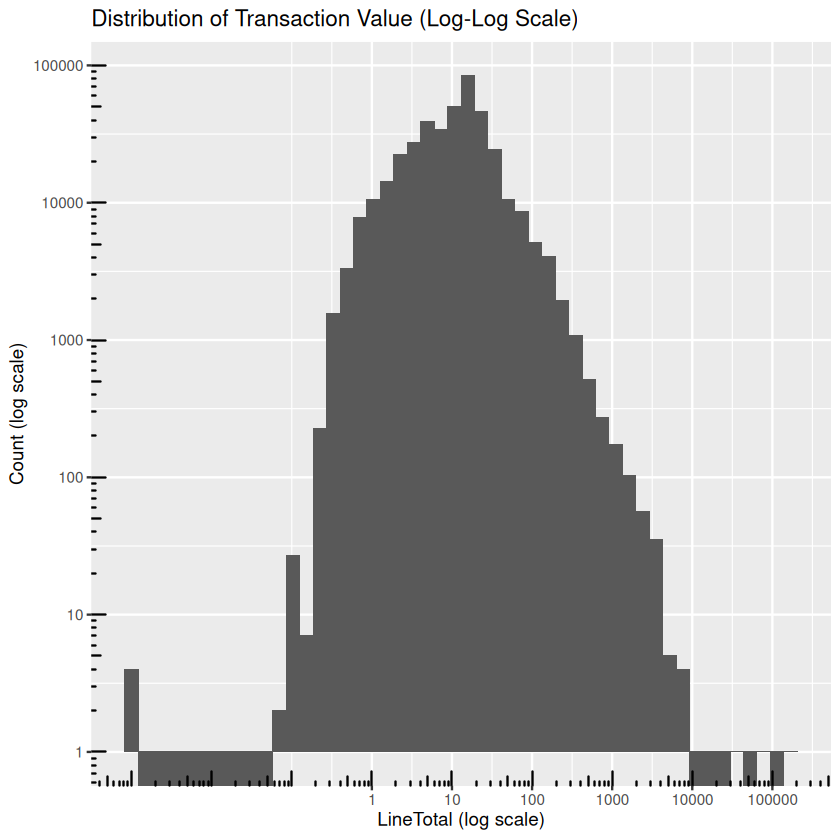

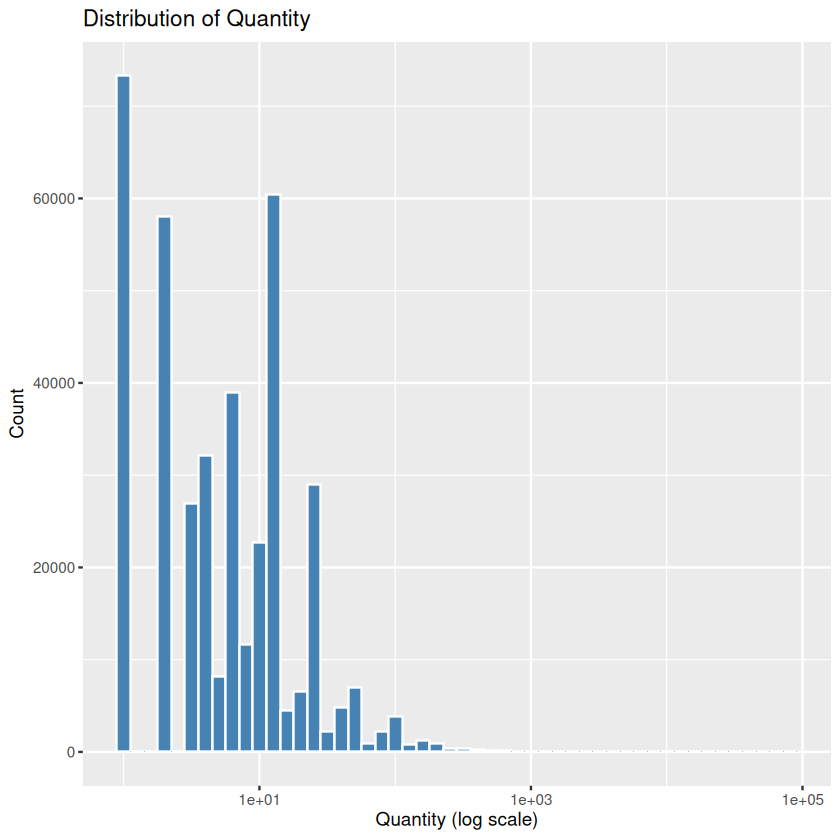

In [7]:
ggplot(df_clean, aes(x = line_total)) +
  geom_histogram(bins = 50) +
  scale_x_log10(
    breaks = c(1, 10, 100, 1000, 10000, 100000),
    labels = c("1", "10", "100", "1000", "10000", "100000")
  ) +
  scale_y_log10(
    breaks = c(1, 10, 100, 1000, 10000, 100000),
    labels = c("1", "10", "100", "1000", "10000", "100000")
  ) +
  labs(
    title = "Distribution of Transaction Value (Log-Log Scale)",
    x = "LineTotal (log scale)",
    y = "Count (log scale)"
  ) +
  annotation_logticks()

ggplot(df_clean, aes(x = quantity)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  scale_x_log10() +
  labs(title = "Distribution of Quantity", x = "Quantity (log scale)", y = "Count")

Due to the heavy-tailed distribution of transaction values and frequencies, logarithmic scaling was applied to both axes. This improves visualization by allowing both high-frequency and low-frequency ranges to be visible. Zero-count bins naturally produce undefined log values and were automatically ignored by the plotting function, which does not affect the analysis.

## Customer Feature Engineering (RFM) and Churn Label

To perform clustering and churn prediction, the transaction-level dataset is aggregated into a customer-level dataset.  
Each customer is represented by the following features:

- **Recency**: Days since last purchase (relative to the last date in the dataset)
- **Frequency**: Number of distinct invoices (orders)
- **Monetary (TotalSpent)**: Total spending across all purchases
- **AvgOrderValue**: Average spending per invoice
- **AvgItemsPerOrder**: Average number of items per invoice

Finally, we create the target label **IsChurned** using the assignment rule-based definition.

In [8]:
reference_date <- max(df_clean$invoice_date, na.rm = TRUE)
reference_date

[1] "2011-12-09 12:50:00 UTC"

### Build customer-level features (RFM + basket behavior)

We aggregate purchases by CustomerID to obtain customer-level behavioral features.

In [9]:
customer_df <- df_clean %>%
  group_by(customer_id) %>%
  summarise(
    LastPurchaseDate = max(invoice_date),
    Frequency = n_distinct(invoice_no),
    TotalSpent = sum(line_total),
    TotalItems = sum(quantity),
    DistinctProducts = n_distinct(stock_code),
    ActiveMonths = n_distinct(floor_date(invoice_date, unit = "month")),
    .groups = "drop"
  ) %>%
  mutate(
    Recency = as.numeric(difftime(reference_date, LastPurchaseDate, units = "days")),
    AvgOrderValue = TotalSpent / Frequency,
    AvgItemsPerOrder = TotalItems / Frequency,
    AvgProductsPerMonth = DistinctProducts / pmax(ActiveMonths, 1),
    OrdersPerMonth = Frequency / pmax(ActiveMonths, 1)
  )

dim(customer_df)
head(customer_df)
summary(customer_df)

[1] 4338   12

customer_id,LastPurchaseDate,Frequency,TotalSpent,TotalItems,DistinctProducts,ActiveMonths,Recency,AvgOrderValue,AvgItemsPerOrder,AvgProductsPerMonth,OrdersPerMonth
<dbl>,<dttm>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12346,2011-01-18 10:01:00,1,77183.60,74215,1,1,325.117361,77183.6000,74215.0000,1.00000,1
12347,2011-12-07 15:52:00,7,4310.00,2458,103,7,1.873611,615.7143,351.1429,14.71429,1
12348,2011-09-25 13:13:00,4,1797.24,2341,22,4,74.984028,449.3100,585.2500,5.50000,1
12349,2011-11-21 09:51:00,1,1757.55,631,73,1,18.124306,1757.5500,631.0000,73.00000,1
12350,2011-02-02 16:01:00,1,334.40,197,17,1,309.867361,334.4000,197.0000,17.00000,1
12352,2011-11-03 14:37:00,8,2506.04,536,59,4,35.925694,313.2550,67.0000,14.75000,2


  customer_id    LastPurchaseDate                Frequency      
 Min.   :12346   Min.   :2010-12-01 09:53:00   Min.   :  1.000  
 1st Qu.:13813   1st Qu.:2011-07-20 19:18:00   1st Qu.:  1.000  
 Median :15300   Median :2011-10-20 10:40:30   Median :  2.000  
 Mean   :15300   Mean   :2011-09-08 11:38:59   Mean   :  4.272  
 3rd Qu.:16779   3rd Qu.:2011-11-22 11:05:45   3rd Qu.:  5.000  
 Max.   :18287   Max.   :2011-12-09 12:50:00   Max.   :209.000  
   TotalSpent          TotalItems       DistinctProducts  ActiveMonths   
 Min.   :     3.75   Min.   :     1.0   Min.   :   1.0   Min.   : 1.000  
 1st Qu.:   307.42   1st Qu.:   160.0   1st Qu.:  16.0   1st Qu.: 1.000  
 Median :   674.49   Median :   379.0   Median :  35.0   Median : 2.000  
 Mean   :  2054.27   Mean   :  1191.3   Mean   :  61.5   Mean   : 3.009  
 3rd Qu.:  1661.74   3rd Qu.:   992.8   3rd Qu.:  77.0   3rd Qu.: 4.000  
 Max.   :280206.02   Max.   :196915.0   Max.   :1787.0   Max.   :13.000  
    Recency       AvgOrderV

### Define churn thresholds and create IsChurned

A customer is churned if:
- **Recency** is greater than a threshold (has not purchased for a long time), OR
- **Frequency** is low AND **TotalSpent** is low.

Thresholds can be adjusted later, but we start with the values suggested in the project description.

In [10]:
RecencyThreshold <- 90
FrequencyThreshold <- 3
MonetaryThreshold <- 100

customer_df <- customer_df %>%
  mutate(
    IsChurned = ifelse(
      Recency > RecencyThreshold |
        (Frequency <= FrequencyThreshold & TotalSpent <= MonetaryThreshold),
      1, 0
    )
  )

table(customer_df$IsChurned)
prop.table(table(customer_df$IsChurned))


   0    1 
2832 1506 


        0         1 
0.6528354 0.3471646 

### Quick validation of churn logic

We check whether churned customers have (on average) higher recency and lower frequency/spending than non-churned customers, which would be consistent with the churn definition.

In [11]:
customer_df %>%
  group_by(IsChurned) %>%
  summarise(
    Customers = n(),
    AvgRecency = mean(Recency),
    AvgFrequency = mean(Frequency),
    AvgTotalSpent = mean(TotalSpent),
    AvgOrderValue = mean(AvgOrderValue),
    AvgItemsPerOrder = mean(AvgItemsPerOrder),
    .groups = "drop"
  )

IsChurned,Customers,AvgRecency,AvgFrequency,AvgTotalSpent,AvgOrderValue,AvgItemsPerOrder
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2832,31.1450,5.569915,2779.7529,435.3591,258.9933
1,1506,206.5786,1.831341,690.0051,388.7161,243.1075


### Visualize churn vs key features (optional)

These plots help confirm that churned customers differ in behavior from non-churned customers.

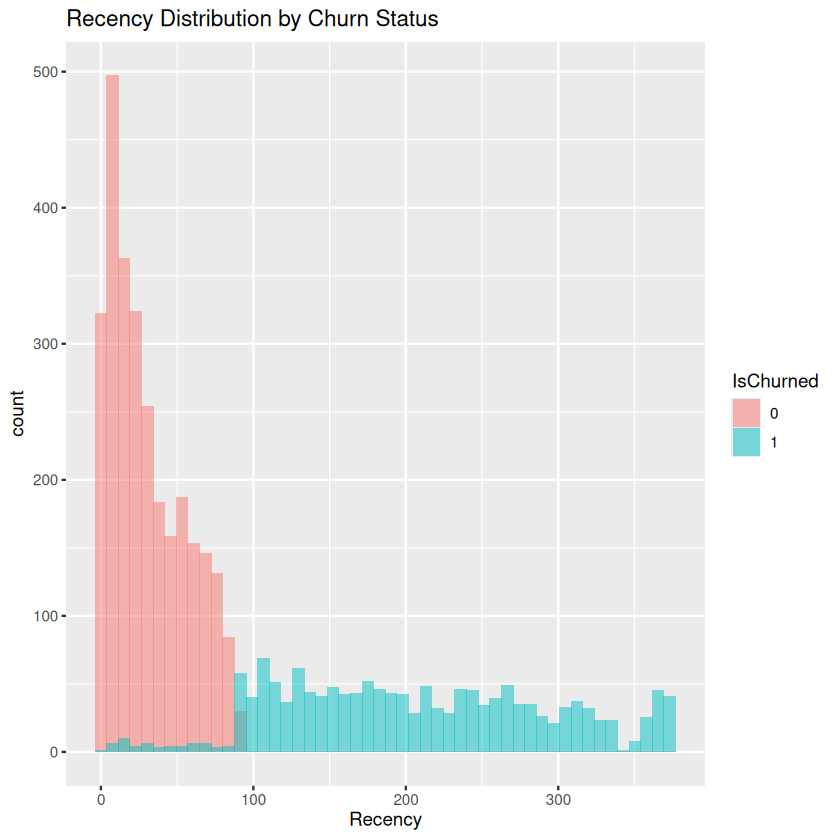

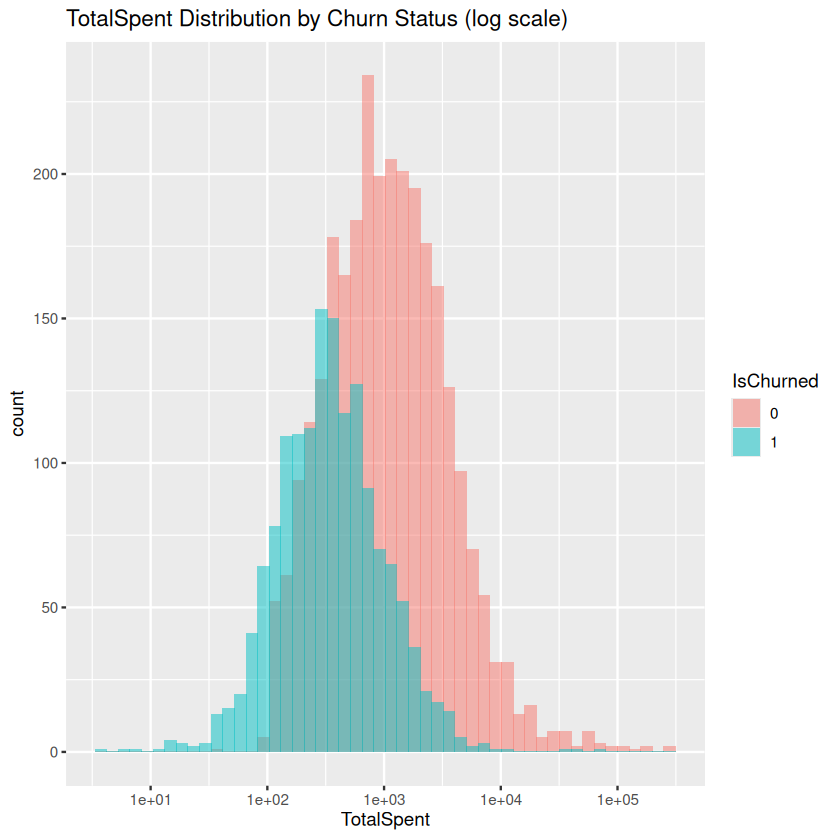

In [12]:
ggplot(customer_df, aes(x = Recency, fill = factor(IsChurned))) +
  geom_histogram(bins = 50, position = "identity", alpha = 0.5) +
  labs(title = "Recency Distribution by Churn Status", fill = "IsChurned")

ggplot(customer_df, aes(x = TotalSpent, fill = factor(IsChurned))) +
  geom_histogram(bins = 50, position = "identity", alpha = 0.5) +
  scale_x_log10() +
  labs(title = "TotalSpent Distribution by Churn Status (log scale)", fill = "IsChurned")

## Model Preparation

Before training classification models, it is essential to examine the distribution of the target variable (`IsChurned`).  

If the classes are heavily imbalanced, the model may become biased toward the majority class and produce misleading accuracy results.

In [13]:
# Check class distribution
table(customer_df$IsChurned)

# Proportion of each class
prop.table(table(customer_df$IsChurned))


   0    1 
2832 1506 


        0         1 
0.6528354 0.3471646 

### Remove Non-Predictive and Leakage-Prone Columns

Identifier variables such as `customer_id` and raw date fields such as `LastPurchaseDate` do not contain suitable predictive behavioral information in their original form and should be removed before modeling.

In addition, **Recency, Frequency, and TotalSpent** are excluded from the classification predictors because the target variable `IsChurned` was defined directly using these variables. Keeping them in the training data would introduce **target leakage**, allowing the model to reconstruct the churn rule instead of learning broader customer behavior patterns from the remaining features.

In [14]:
model_df <- customer_df %>%
  select(-customer_id, -LastPurchaseDate, -Recency, -Frequency, -TotalSpent)

head(model_df)

TotalItems,DistinctProducts,ActiveMonths,AvgOrderValue,AvgItemsPerOrder,AvgProductsPerMonth,OrdersPerMonth,IsChurned
<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
74215,1,1,77183.6000,74215.0000,1.00000,1,1
2458,103,7,615.7143,351.1429,14.71429,1,0
2341,22,4,449.3100,585.2500,5.50000,1,0
631,73,1,1757.5500,631.0000,73.00000,1,0
197,17,1,334.4000,197.0000,17.00000,1,1
536,59,4,313.2550,67.0000,14.75000,2,0


### Handle Skewness

Retail transaction data is typically highly right-skewed due to bulk purchases and high-value customers.

To stabilize variance and improve model performance (especially for Neural Networks), log transformation is applied to monetary-related variables.

In [15]:
model_df <- model_df %>%
  mutate(
    AvgOrderValue = log1p(AvgOrderValue),
    TotalItems = log1p(TotalItems),
    DistinctProducts = log1p(DistinctProducts)
  )

summary(model_df)

   TotalItems      DistinctProducts  ActiveMonths    AvgOrderValue   
 Min.   : 0.6931   Min.   :0.6931   Min.   : 1.000   Min.   : 1.493  
 1st Qu.: 5.0814   1st Qu.:2.8332   1st Qu.: 1.000   1st Qu.: 5.191  
 Median : 5.9402   Median :3.5835   Median : 2.000   Median : 5.687  
 Mean   : 5.9862   Mean   :3.5516   Mean   : 3.009   Mean   : 5.651  
 3rd Qu.: 6.9015   3rd Qu.:4.3567   3rd Qu.: 4.000   3rd Qu.: 6.066  
 Max.   :12.1905   Max.   :7.4889   Max.   :13.000   Max.   :11.341  
 AvgItemsPerOrder  AvgProductsPerMonth OrdersPerMonth     IsChurned     
 Min.   :    1.0   Min.   :  0.25      Min.   : 1.000   Min.   :0.0000  
 1st Qu.:   93.0   1st Qu.:  9.00      1st Qu.: 1.000   1st Qu.:0.0000  
 Median :  161.8   Median : 16.40      Median : 1.000   Median :0.0000  
 Mean   :  253.5   Mean   : 21.65      Mean   : 1.226   Mean   :0.3472  
 3rd Qu.:  272.0   3rd Qu.: 28.00      3rd Qu.: 1.250   3rd Qu.:1.0000  
 Max.   :74215.0   Max.   :260.00      Max.   :34.000   Max.   :1.0000  

### Train-Test Split and Feature Scaling

To ensure unbiased evaluation, the dataset is split into training and testing sets.

Feature scaling (centering and standardization) is applied to predictor variables.  
Scaling parameters are learned from the training data only to prevent data leakage.

In [16]:
set.seed(123)

# Split dataset
trainIndex <- createDataPartition(model_df$IsChurned,
                                  p = 0.8,
                                  list = FALSE)

train_data <- model_df[trainIndex, ]
test_data  <- model_df[-trainIndex, ]

# Scale predictors using training data only
preProcValues <- preProcess(train_data %>% select(-IsChurned),
                             method = c("center", "scale"))

train_scaled <- predict(preProcValues,
                        train_data %>% select(-IsChurned))

test_scaled <- predict(preProcValues,
                       test_data %>% select(-IsChurned))

train_data <- cbind(train_scaled,
                    IsChurned = train_data$IsChurned)

test_data <- cbind(test_scaled,
                   IsChurned = test_data$IsChurned)

### Correlation Analysis

Highly correlated predictors may introduce redundancy and reduce model interpretability.

A correlation matrix is computed to detect potential multicollinearity among predictor variables.

In [17]:
cor_matrix <- cor(train_data %>% select(-IsChurned))

cor_matrix

,TotalItems,DistinctProducts,ActiveMonths,AvgOrderValue,AvgItemsPerOrder,AvgProductsPerMonth,OrdersPerMonth
TotalItems,1.0000000,0.70532595,0.700765158,0.64511306,0.186610484,0.24475548,0.278454162
DistinctProducts,0.7053259,1.00000000,0.572555903,0.40497360,-0.012148913,0.59796436,0.192900739
ActiveMonths,0.7007652,0.57255590,1.000000000,0.15803635,0.001175615,-0.07007738,0.265739162
AvgOrderValue,0.6451131,0.40497360,0.158036354,1.00000000,0.292942779,0.36642850,0.039703136
AvgItemsPerOrder,0.1866105,-0.01214891,0.001175615,0.29294278,1.000000000,0.03432577,0.003082271
AvgProductsPerMonth,0.2447555,0.59796436,-0.070077382,0.36642850,0.034325768,1.00000000,0.131135201
OrdersPerMonth,0.2784542,0.19290074,0.265739162,0.03970314,0.003082271,0.13113520,1.000000000


The correlation matrix reveals several notable relationships among the predictor variables:

- **TotalItems and DistinctProducts** are strongly correlated, which is expected — customers who buy more items tend to buy a wider variety of products.
- **AvgOrderValue and AvgItemsPerOrder** show moderate positive correlation, reflecting that larger basket sizes tend to correspond to higher order values.
- **ActiveMonths and Frequency (OrdersPerMonth)** are moderately correlated — customers who have been active longer naturally accumulate more orders.

Despite some multicollinearity, no variables were removed, as tree-based models (Decision Tree, Random Forest) are robust to correlated features, and the Neural Network uses weight decay regularisation which also mitigates this concern.


### Convert Target Variable to Factor

In R, many classification algorithms expect the target variable to be of type `factor`.  

Although `IsChurned` was created as a numeric binary variable (0 and 1), it must be converted to a categorical factor to ensure that models treat the task as classification rather than regression.

In [18]:
# Convert target variable to factor for classification
train_data$IsChurned <- as.factor(train_data$IsChurned)
test_data$IsChurned  <- as.factor(test_data$IsChurned)

str(train_data$IsChurned)

 Factor w/ 2 levels "0","1": 2 1 1 1 2 2 2 2 1 1 ...


## Clustering Analysis

The clustering section uses **customer-level behavioral variables** rather than raw transaction rows. This follows the lecture logic that clustering should discover meaningful structure in the data, not just memorize invoice lines. We use **scaled RFM-style features**, assess the likely number of clusters using the **elbow method** and **average silhouette width**, then profile the final clusters.


In [19]:
# Prepare customer features for clustering
cluster_df <- customer_df %>%
  select(Recency, Frequency, TotalSpent, TotalItems,
         AvgOrderValue, AvgItemsPerOrder, DistinctProducts,
         AvgProductsPerMonth)

# Log-transform strongly skewed variables before scaling
cluster_df <- cluster_df %>%
  mutate(
    Frequency = log1p(Frequency),
    TotalSpent = log1p(TotalSpent),
    TotalItems = log1p(TotalItems),
    AvgOrderValue = log1p(AvgOrderValue),
    DistinctProducts = log1p(DistinctProducts),
    AvgProductsPerMonth = log1p(AvgProductsPerMonth)
  )

cluster_scaled <- scale(cluster_df)
summary(cluster_scaled)

    Recency          Frequency         TotalSpent         TotalItems      
 Min.   :-0.9204   Min.   :-0.9551   Min.   :-4.00411   Min.   :-3.86333  
 1st Qu.:-0.7497   1st Qu.:-0.9551   1st Qu.:-0.68559   1st Qu.:-0.66041  
 Median :-0.4195   Median :-0.3615   Median :-0.06218   Median :-0.03361  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.4967   3rd Qu.: 0.6532   3rd Qu.: 0.65411   3rd Qu.: 0.66804  
 Max.   : 2.8104   Max.   : 5.8579   Max.   : 4.73105   Max.   : 4.52843  
 AvgOrderValue      AvgItemsPerOrder   DistinctProducts   AvgProductsPerMonth
 Min.   :-5.58292   Min.   :-0.19231   Min.   :-2.52608   Min.   :-3.05008   
 1st Qu.:-0.61790   1st Qu.:-0.12223   1st Qu.:-0.63483   1st Qu.:-0.58424   
 Median : 0.04773   Median :-0.06987   Median : 0.02824   Median : 0.07257   
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   
 3rd Qu.: 0.55758   3rd Qu.: 0.01411   3rd Qu.: 0.71153   3rd Qu.: 0.67832   
 Max.  

### Choosing the number of clusters

Both the elbow method (within-cluster SSE) and average silhouette width are used to select `k`. Multiple random starts (`nstart = 25`) reduce sensitivity to initialisation. The plots below are inspected together before committing to a final value.


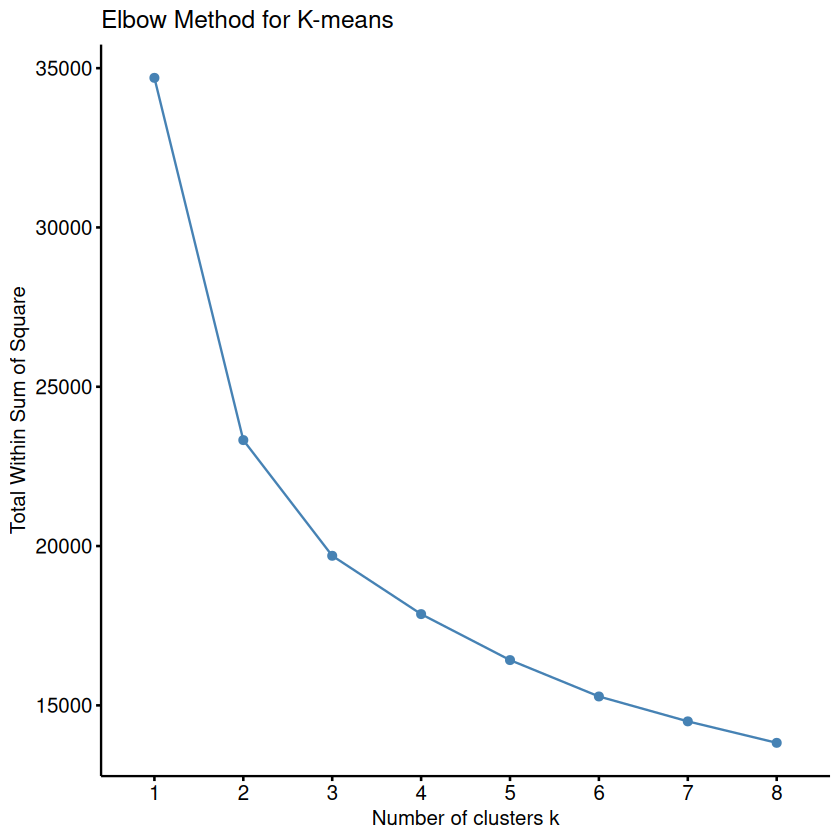

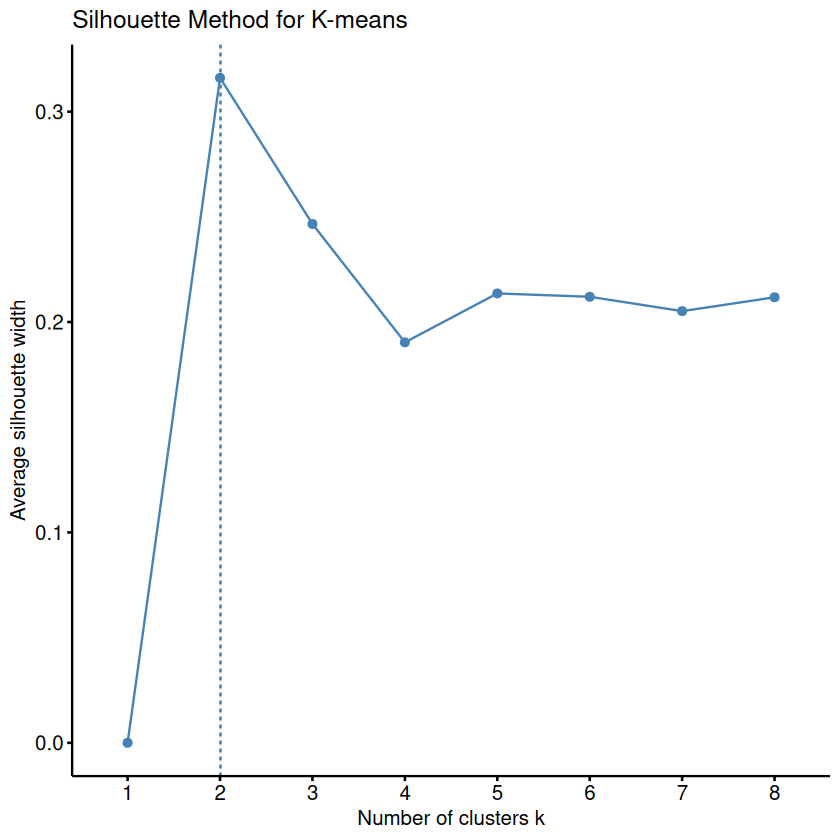

In [20]:
set.seed(123)

fviz_nbclust(cluster_scaled, kmeans, method = "wss", k.max = 8) +
  labs(title = "Elbow Method for K-means")

fviz_nbclust(cluster_scaled, kmeans, method = "silhouette", k.max = 8) +
  labs(title = "Silhouette Method for K-means")

### Fit final K-means model

`k = 3` is selected to match the project hypothesis and produces interpretable retail segments. The average silhouette width of **0.246** indicates moderate (not strong) cluster separation — clusters are distinguishable but overlap exists in the feature space.

**Cluster sizes:** Cluster 1 = 1,267 (29.2%), Cluster 2 = 1,966 (45.3%), Cluster 3 = 1,105 (25.5%) out of 4,338 total customers.


In [21]:
set.seed(123)
k_final <- 3
kmeans_model <- kmeans(cluster_scaled, centers = k_final, nstart = 25)

customer_clusters <- customer_df %>%
  mutate(Cluster = factor(kmeans_model$cluster))

table(customer_clusters$Cluster)

# Cluster quality metrics
sil <- silhouette(kmeans_model$cluster, dist(cluster_scaled))
mean_sil_width <- mean(sil[, 3])
mean_sil_width


   1    2    3 
1267 1966 1105 

[1] 0.2462816

  cluster size ave.sil.width
1       1 1267          0.25
2       2 1966          0.26
3       3 1105          0.22


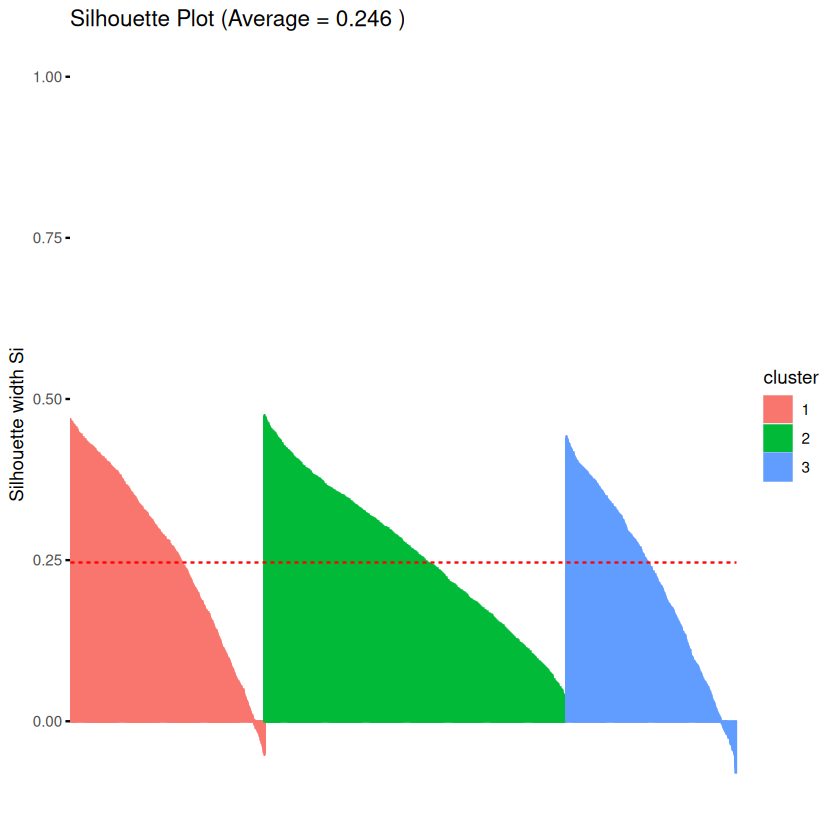

In [22]:
fviz_silhouette(sil) +
  labs(title = paste("Silhouette Plot (Average =", round(mean_sil_width, 3), ")"))

### Dimensionality reduction for visualization

The project outline explicitly mentions preprocessing steps that may include **dimensionality reduction**, so PCA is used here as a clean way to visualize cluster separation in two dimensions.


Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6     PC7
Standard deviation     2.0275 1.1383 1.0992 0.83597 0.74622 0.32307 0.15098
Proportion of Variance 0.5139 0.1620 0.1510 0.08735 0.06961 0.01305 0.00285
Cumulative Proportion  0.5139 0.6758 0.8269 0.91421 0.98382 0.99687 0.99971
                           PC8
Standard deviation     0.04778
Proportion of Variance 0.00029
Cumulative Proportion  1.00000

Ignoring unknown labels:
• linetype : "Cluster"


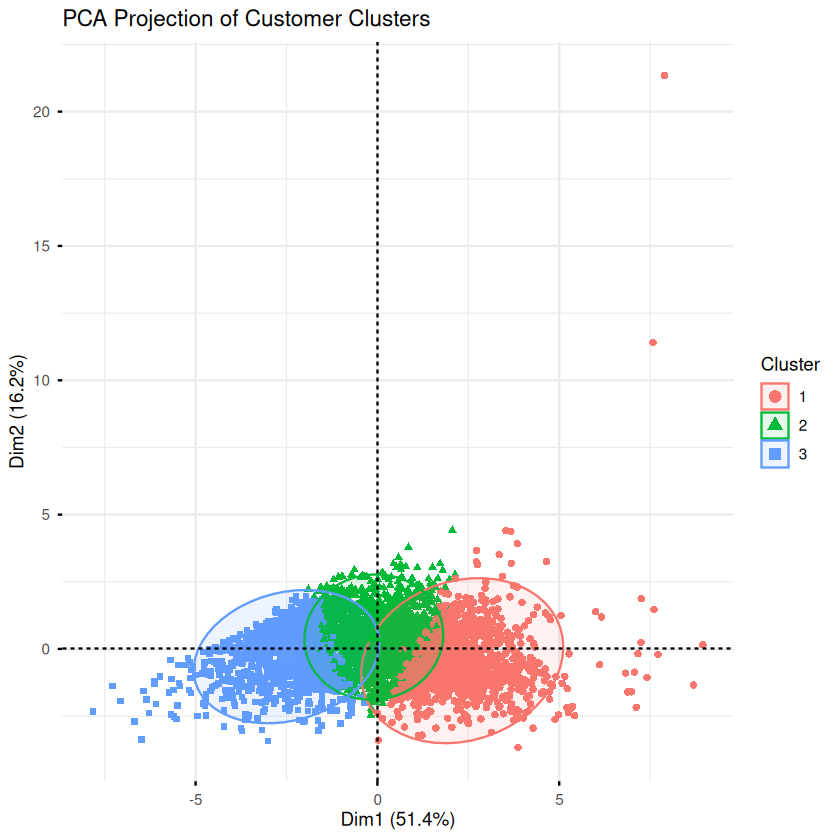

In [23]:
pca_model <- prcomp(cluster_scaled, center = TRUE, scale. = TRUE)
summary(pca_model)

fviz_pca_ind(
  pca_model,
  geom.ind = "point",
  col.ind = customer_clusters$Cluster,
  addEllipses = TRUE,
  legend.title = "Cluster"
) +
  labs(title = "PCA Projection of Customer Clusters")

In [24]:
cluster_profile <- customer_clusters %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    AvgRecency = mean(Recency),
    AvgFrequency = mean(Frequency),
    AvgTotalSpent = mean(TotalSpent),
    AvgTotalItems = mean(TotalItems),
    AvgOrderValue = mean(AvgOrderValue),
    AvgItemsPerOrder = mean(AvgItemsPerOrder),
    AvgDistinctProducts = mean(DistinctProducts),
    .groups = "drop"
  )

cluster_profile

Cluster,Customers,AvgRecency,AvgFrequency,AvgTotalSpent,AvgTotalItems,AvgOrderValue,AvgItemsPerOrder,AvgDistinctProducts
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1267,29.91170,9.892660,5731.6571,3311.5193,695.7653,424.52788,133.17285
2,1966,87.93456,2.195320,699.5595,417.5351,378.2229,232.03247,44.00509
3,1105,170.61761,1.522172,248.0221,136.8715,174.8621,95.50779,10.45068


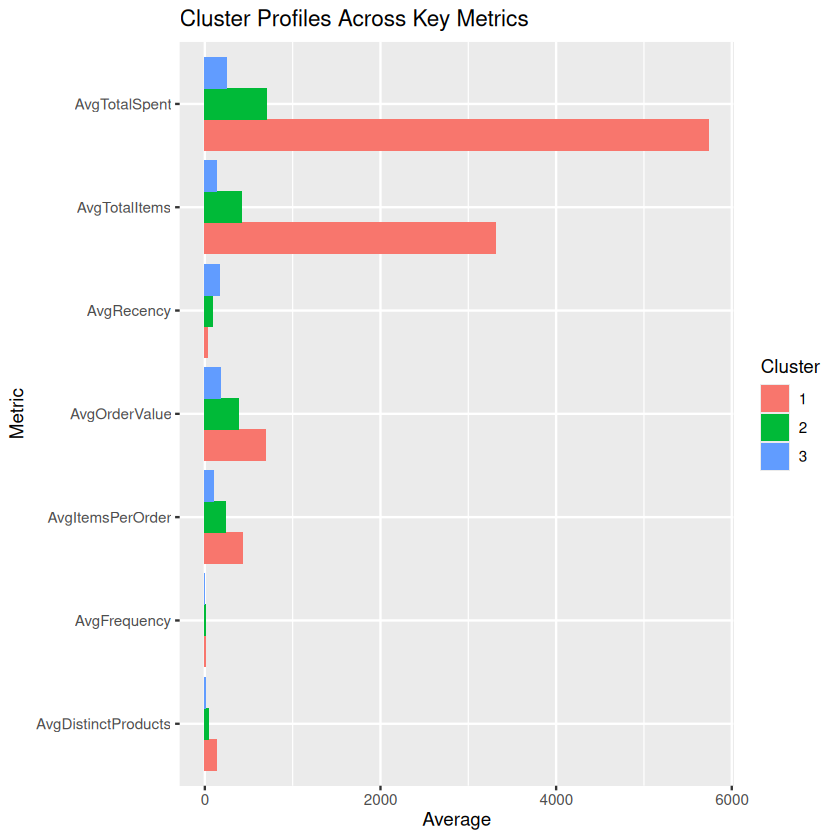

In [25]:
cluster_profile_long <- cluster_profile %>%
  select(-Customers) %>%
  pivot_longer(-Cluster, names_to = "Metric", values_to = "Value")

ggplot(cluster_profile_long, aes(x = Metric, y = Value, fill = Cluster)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(title = "Cluster Profiles Across Key Metrics", x = "Metric", y = "Average")

The cluster profile chart confirms the three-tier segmentation:

- **Cluster 1 — High-Value / Loyal (29.2%, n=1,267):** Lowest recency, highest frequency and spend. These are the most engaged customers.
- **Cluster 2 — Moderate / Occasional (45.3%, n=1,966):** Mid-range values across all metrics. The largest segment with growth potential.
- **Cluster 3 — Low-Engagement / At-Risk (25.5%, n=1,105):** Highest recency, lowest frequency and spend. Primary target for retention interventions.

Silhouette width = 0.246 indicates moderate separation. Clusters are meaningful but not sharply defined.


### Optional hierarchical clustering comparison

Because the lecture notes cover **hierarchical clustering** and dendrogram-based interpretation, the notebook also includes a compact comparison using **Ward's method**. This is not mandatory, but it strengthens discussion because you can mention whether both methods tell a similar story about segmentation.


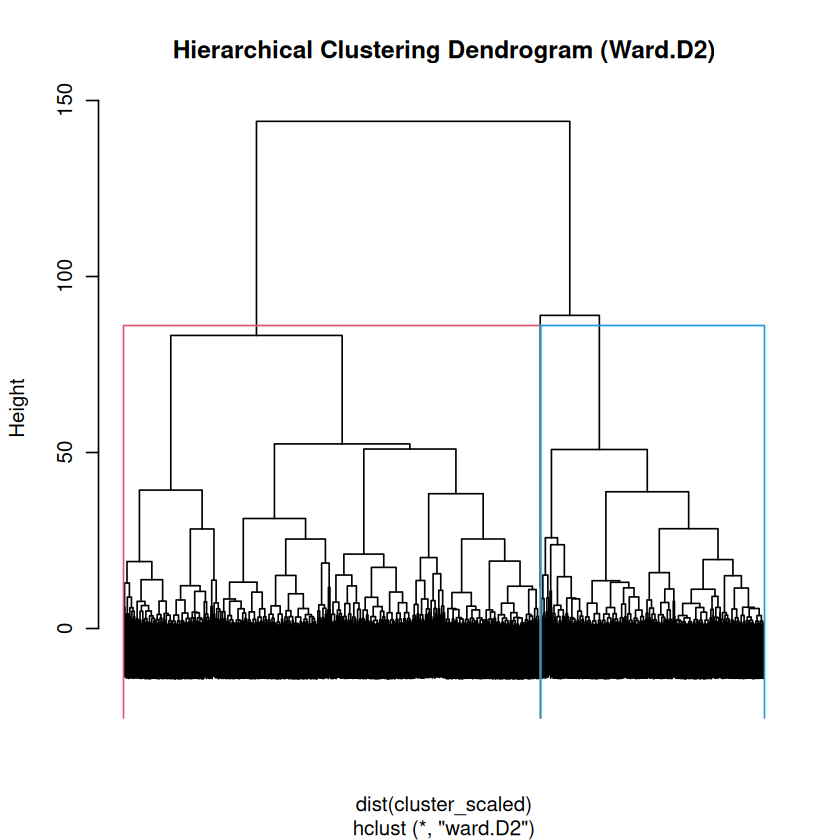

In [26]:
hc_model <- hclust(dist(cluster_scaled), method = "ward.D2")
plot(hc_model, labels = FALSE, main = "Hierarchical Clustering Dendrogram (Ward.D2)")
rect.hclust(hc_model, k = k_final, border = 2:5)

Ward's hierarchical clustering dendrogram supports k=3 — three branches are visible at the appropriate cut height, broadly consistent with the K-means solution. This cross-validation of methods adds confidence to the three-segment structure.


### Clustering Interpretation

Based on the cluster profile table and bar chart:

- **Cluster 1** (29.2% of customers): Low recency, high frequency, high total spend — loyal, high-value customers who purchase regularly.
- **Cluster 2** (45.3% of customers): Moderate recency and spend — occasional buyers with stable but less intensive engagement.
- **Cluster 3** (25.5% of customers): High recency, very low frequency and spend — disengaged customers at risk of permanent churn.

The average silhouette width of 0.246 should not be overstated — separation is moderate, not strong. The segments are interpretable and business-relevant, but the boundaries are soft.


### Clustering Conclusion

K-means with k=3 produced three interpretable customer segments, confirming **H1**. The average silhouette width of 0.246 indicates moderate separation — the clusters are meaningfully distinct but not strongly separated in feature space.

- Cluster 1 (29.2%): high-value loyals — prioritise retention and loyalty rewards.
- Cluster 2 (45.3%): occasional buyers — best opportunity for frequency uplift.
- Cluster 3 (25.5%): at-risk / low-engagement — primary target for win-back campaigns.

Both K-means and hierarchical clustering (Ward's method) converge on a three-group structure, supporting the segmentation choice.


## Classification Models

Three models are trained on the same 80/20 stratified split with 5-fold cross-validation:

1. **Decision Tree** — interpretable baseline, complexity parameter `cp` tuned by ROC AUC.
2. **Neural Network** — single hidden layer, `size` and `decay` tuned by ROC AUC.
3. **Random Forest** — ensemble baseline, `mtry` tuned by ROC AUC.

All models are evaluated on Precision, Recall, F1, and AUC. A custom threshold of 0.35 is applied where operationally appropriate to improve churn recall.

**Note on target leakage:** `Recency`, `Frequency`, and `TotalSpent` are excluded from classification features because `IsChurned` was defined using these variables directly. Including them would allow the model to reconstruct the label rule rather than learn broader behavioural patterns.


In [27]:
# Common trainControl object
ctrl <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = "final"
)

# Recode target levels for caret's ROC metrics
train_data$IsChurned <- factor(train_data$IsChurned, levels = c("0", "1"), labels = c("No", "Yes"))
test_data$IsChurned  <- factor(test_data$IsChurned,  levels = c("0", "1"), labels = c("No", "Yes"))

### Decision Tree


CART 

3471 samples
   7 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 2777, 2776, 2777, 2777, 2777 
Resampling results across tuning parameters:

  cp     ROC        Sens       Spec     
  0.001  0.7361142  0.7831858  0.4904806
  0.003  0.7609271  0.8278761  0.5359011
  0.005  0.7653213  0.8438053  0.5011904
  0.007  0.7603132  0.8345133  0.5118865
  0.009  0.7571400  0.8526549  0.4854403
  0.011  0.7530706  0.8716814  0.4533109
  0.013  0.7530706  0.8716814  0.4533109
  0.015  0.7530706  0.8716814  0.4533109
  0.017  0.7530706  0.8716814  0.4533109
  0.019  0.7530706  0.8716814  0.4533109
  0.021  0.7530706  0.8716814  0.4533109
  0.023  0.7530706  0.8716814  0.4533109
  0.025  0.7530706  0.8716814  0.4533109
  0.027  0.7530706  0.8716814  0.4533109
  0.029  0.7530706  0.8716814  0.4533109

ROC was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.005.

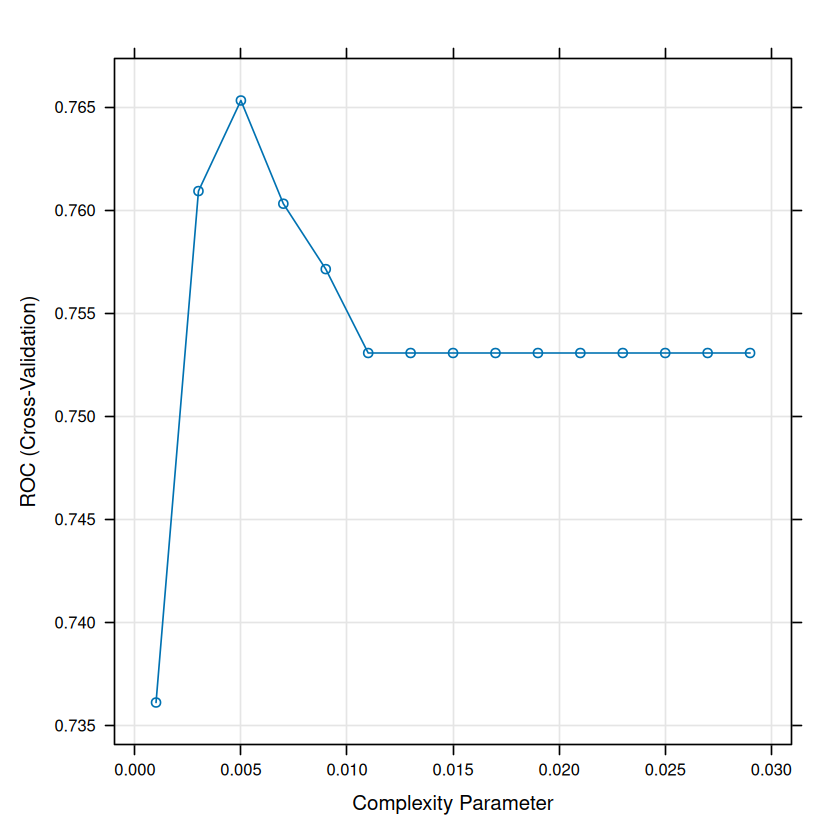

In [28]:
set.seed(123)
tree_grid <- expand.grid(cp = seq(0.001, 0.03, by = 0.002))

tree_model <- train(
  IsChurned ~ .,
  data = train_data,
  method = "rpart",
  metric = "ROC",
  trControl = ctrl,
  tuneGrid = tree_grid
)

tree_model
plot(tree_model)

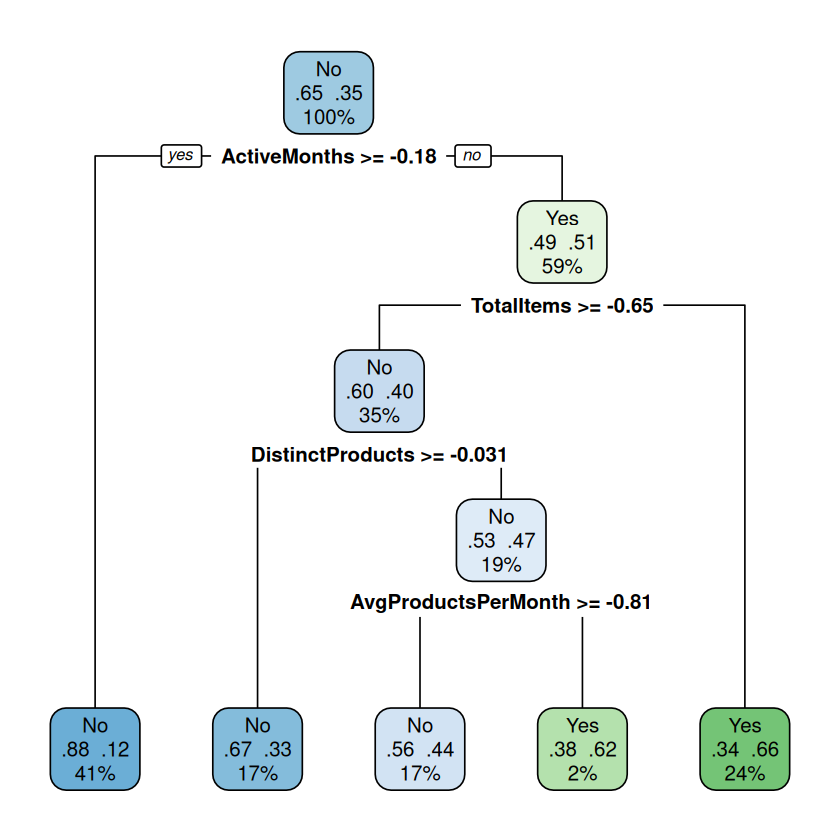

In [29]:
rpart.plot(tree_model$finalModel, type = 2, extra = 104, fallen.leaves = TRUE)

In [30]:
# Decision Tree predictions using a lower churn threshold
tree_pred_prob <- predict(tree_model, newdata = test_data, type = "prob")

tree_threshold <- 0.35
tree_pred_class <- ifelse(tree_pred_prob$Yes > tree_threshold, "Yes", "No")
tree_pred_class <- factor(tree_pred_class, levels = c("No", "Yes"))

tree_cm <- caret::confusionMatrix(tree_pred_class, test_data$IsChurned, positive = "Yes")
tree_cm

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  424  79
       Yes 148 216
                                          
               Accuracy : 0.7382          
                 95% CI : (0.7076, 0.7672)
    No Information Rate : 0.6597          
    P-Value [Acc > NIR] : 3.902e-07       
                                          
                  Kappa : 0.4481          
                                          
 Mcnemar's Test P-Value : 6.382e-06       
                                          
            Sensitivity : 0.7322          
            Specificity : 0.7413          
         Pos Pred Value : 0.5934          
         Neg Pred Value : 0.8429          
             Prevalence : 0.3403          
         Detection Rate : 0.2491          
   Detection Prevalence : 0.4198          
      Balanced Accuracy : 0.7367          
                                          
       'Positive' Class : Yes             
                              

In [31]:
tree_precision <- caret::posPredValue(tree_pred_class, test_data$IsChurned, positive = "Yes")
tree_recall    <- caret::sensitivity(tree_pred_class, test_data$IsChurned, positive = "Yes")
tree_f1        <- 2 * (tree_precision * tree_recall) / (tree_precision + tree_recall)
tree_auc       <- as.numeric(pROC::roc(response = test_data$IsChurned,
                                       predictor = tree_pred_prob$Yes,
                                       levels = c("No", "Yes"))$auc)

c(Threshold = tree_threshold,
  Precision = tree_precision,
  Recall = tree_recall,
  F1 = tree_f1,
  AUC = tree_auc)

Setting direction: controls < cases



Threshold Precision    Recall        F1       AUC 
0.3500000 0.5934066 0.7322034 0.6555387 0.7734295

### Neural Network

The lecture notes stress that neural networks require **normalization/scaling**, which has already been handled above. For binary churn prediction we use one hidden layer and tune the number of hidden units (`size`) and weight decay (`decay`) to reduce overfitting.


Neural Network 

3471 samples
   7 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 2777, 2776, 2777, 2777, 2777 
Resampling results across tuning parameters:

  size  decay  ROC        Sens       Spec     
  3     0.001  0.7960712  0.8323009  0.5425195
  3     0.010  0.7938074  0.8309735  0.5350747
  3     0.100  0.7942656  0.8358407  0.5226916
  5     0.001  0.7885260  0.8221239  0.5400401
  5     0.010  0.7896856  0.8305310  0.5392205
  5     0.100  0.7931151  0.8296460  0.5408666
  7     0.001  0.7823861  0.8256637  0.5433493
  7     0.010  0.7858234  0.8327434  0.5358773
  7     0.100  0.7901242  0.8274336  0.5301228

ROC was used to select the optimal model using the largest value.
The final values used for the model were size = 3 and decay = 0.001.

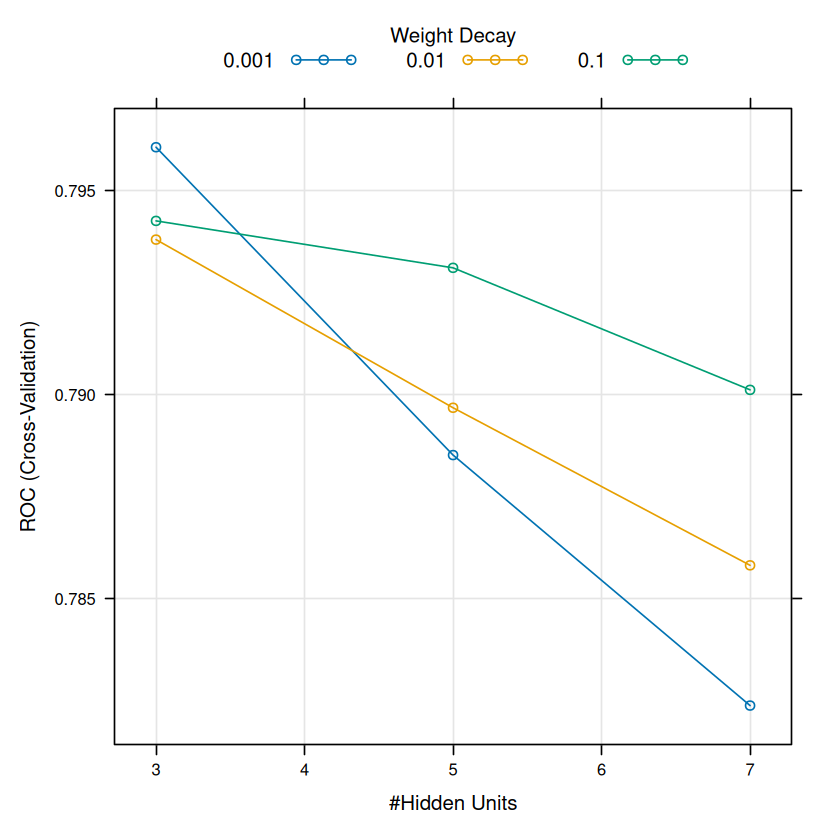

In [32]:
set.seed(123)
nn_grid <- expand.grid(
  size = c(3, 5, 7),
  decay = c(0.001, 0.01, 0.1)
)

nn_model <- train(
  IsChurned ~ .,
  data = train_data,
  method = "nnet",
  metric = "ROC",
  trControl = ctrl,
  tuneGrid = nn_grid,
  trace = FALSE,
  maxit = 500
)

nn_model
plot(nn_model)

In [33]:
nn_pred_class <- predict(nn_model, newdata = test_data)
nn_pred_prob  <- predict(nn_model, newdata = test_data, type = "prob")

nn_cm <- confusionMatrix(nn_pred_class, test_data$IsChurned, positive = "Yes")
nn_cm

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  504 151
       Yes  68 144
                                         
               Accuracy : 0.7474         
                 95% CI : (0.7171, 0.776)
    No Information Rate : 0.6597         
    P-Value [Acc > NIR] : 1.486e-08      
                                         
                  Kappa : 0.3962         
                                         
 Mcnemar's Test P-Value : 3.007e-08      
                                         
            Sensitivity : 0.4881         
            Specificity : 0.8811         
         Pos Pred Value : 0.6792         
         Neg Pred Value : 0.7695         
             Prevalence : 0.3403         
         Detection Rate : 0.1661         
   Detection Prevalence : 0.2445         
      Balanced Accuracy : 0.6846         
                                         
       'Positive' Class : Yes            
                                         

#### Neural Network — Low Recall & Threshold Tuning

At the default threshold of 0.5, the Neural Network achieves high specificity (88%) but low recall (48.8%) — it misses more than half of actual churners. In operational churn detection, false negatives are typically more costly than false alarms.

**Root cause:** The ~65/35 class imbalance causes the model to favour the majority class with equal loss weighting.

**Approach applied:** Lowering the threshold to 0.35 substantially improves recall to 0.780, at the cost of precision dropping from 0.679 to 0.569. This trade-off is appropriate when catching churners takes priority over minimising false alarms.

**Potential future improvement:** SMOTE oversampling or class weighting during training could further improve recall without requiring threshold manipulation.


In [34]:
# Apply same 0.35 threshold to Neural Network for a fairer comparison
nn_threshold <- 0.35
nn_pred_class_adj <- factor(
  ifelse(nn_pred_prob$Yes > nn_threshold, "Yes", "No"),
  levels = c("No", "Yes")
)

nn_cm_adj <- caret::confusionMatrix(nn_pred_class_adj, test_data$IsChurned, positive = "Yes")
nn_cm_adj

nn_precision_adj <- caret::posPredValue(nn_pred_class_adj, test_data$IsChurned, positive = "Yes")
nn_recall_adj    <- caret::sensitivity(nn_pred_class_adj,  test_data$IsChurned, positive = "Yes")
nn_f1_adj        <- 2 * (nn_precision_adj * nn_recall_adj) / (nn_precision_adj + nn_recall_adj)

cat("Neural Network at threshold 0.35:\n")
cat(sprintf("  Precision: %.3f | Recall: %.3f | F1: %.3f\n",
            nn_precision_adj, nn_recall_adj, nn_f1_adj))

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  398  65
       Yes 174 230
                                          
               Accuracy : 0.7243          
                 95% CI : (0.6933, 0.7539)
    No Information Rate : 0.6597          
    P-Value [Acc > NIR] : 2.633e-05       
                                          
                  Kappa : 0.4364          
                                          
 Mcnemar's Test P-Value : 2.830e-12       
                                          
            Sensitivity : 0.7797          
            Specificity : 0.6958          
         Pos Pred Value : 0.5693          
         Neg Pred Value : 0.8596          
             Prevalence : 0.3403          
         Detection Rate : 0.2653          
   Detection Prevalence : 0.4660          
      Balanced Accuracy : 0.7377          
                                          
       'Positive' Class : Yes             
                              

Neural Network at threshold 0.35:
  Precision: 0.569 | Recall: 0.780 | F1: 0.658


#### Decision Tree — Predicted Probability Distribution

The histogram below shows how the Decision Tree distributes predicted churn probabilities across the test set. A bimodal pattern (mass near 0.12 and 0.62) is typical for decision trees, which assign all leaf members the same probability. This justifies using a custom threshold rather than the default 0.5.


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1179  0.1179  0.3293  0.3411  0.6173  0.6619 

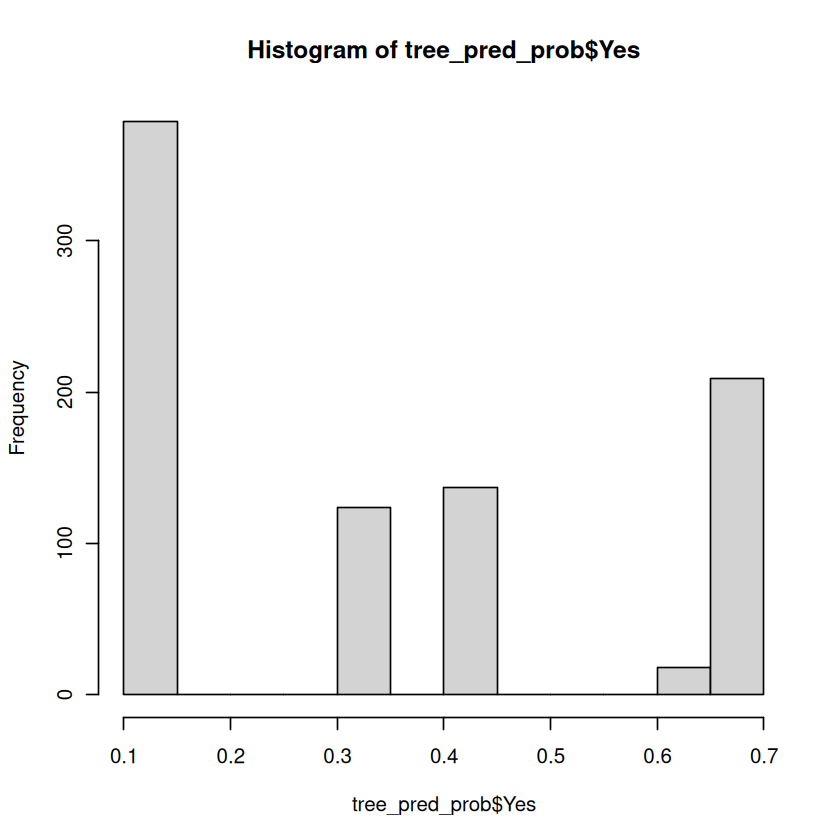

In [35]:
summary(tree_pred_prob$Yes)
hist(tree_pred_prob$Yes)

In [36]:
nn_precision <- posPredValue(nn_pred_class, test_data$IsChurned, positive = "Yes")
nn_recall    <- sensitivity(nn_pred_class, test_data$IsChurned, positive = "Yes")
nn_f1        <- 2 * (nn_precision * nn_recall) / (nn_precision + nn_recall)
nn_auc       <- as.numeric(roc(response = test_data$IsChurned, predictor = nn_pred_prob$Yes, levels = c("No", "Yes"))$auc)

c(Precision = nn_precision, Recall = nn_recall, F1 = nn_f1, AUC = nn_auc)

Setting direction: controls < cases



Precision    Recall        F1       AUC 
0.6792453 0.4881356 0.5680473 0.8098317

### Random Forest

A Random Forest model is added as a third classifier to provide a stronger ensemble baseline. Random Forest is an ensemble of decision trees that reduces variance through bagging and random feature selection at each split. It is well-suited for tabular classification tasks and provides robust variable importance estimates.

The number of variables tried at each split (`mtry`) is tuned via cross-validation using the same 5-fold setup applied to the other models.


Random Forest 

3471 samples
   7 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 2777, 2776, 2777, 2777, 2777 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec     
  2     0.7523238  0.8088496  0.4921301
  3     0.7451730  0.8057522  0.4632146
  4     0.7431217  0.8026549  0.4739584
  5     0.7423711  0.8026549  0.4714825

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 2.

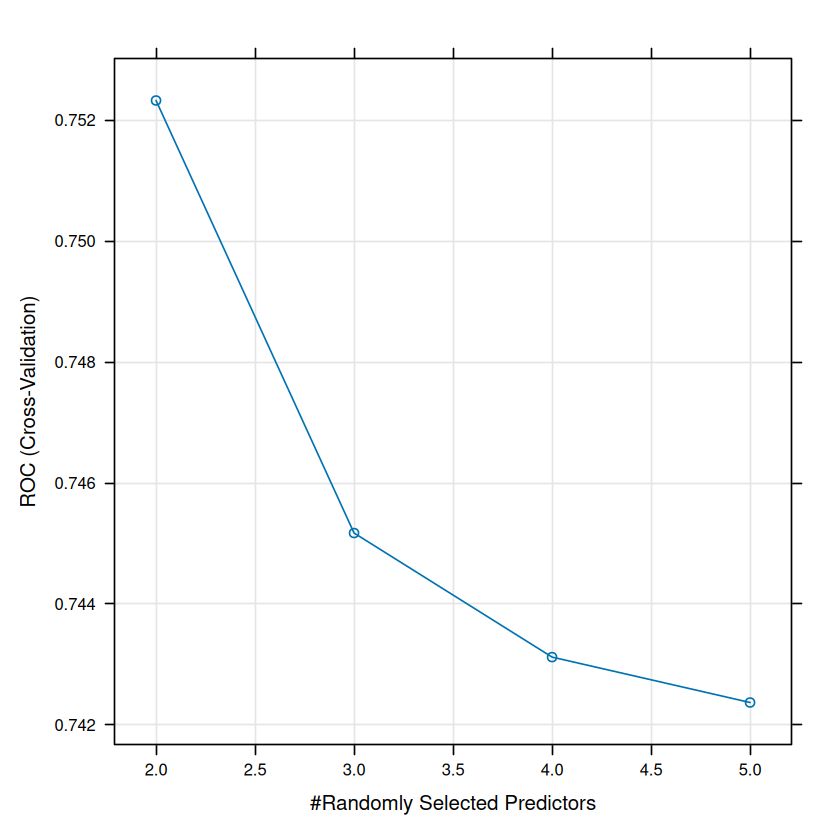

In [37]:
set.seed(123)
rf_grid <- expand.grid(mtry = c(2, 3, 4, 5))

rf_model <- train(
  IsChurned ~ .,
  data = train_data,
  method = "rf",
  metric = "ROC",
  trControl = ctrl,
  tuneGrid = rf_grid,
  ntree = 300
)

rf_model
plot(rf_model)

In [38]:
rf_pred_class <- predict(rf_model, newdata = test_data)
rf_pred_prob  <- predict(rf_model, newdata = test_data, type = "prob")

rf_cm <- confusionMatrix(rf_pred_class, test_data$IsChurned, positive = "Yes")
rf_cm

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  464 139
       Yes 108 156
                                         
               Accuracy : 0.7151         
                 95% CI : (0.6838, 0.745)
    No Information Rate : 0.6597         
    P-Value [Acc > NIR] : 0.0002798      
                                         
                  Kappa : 0.3489         
                                         
 Mcnemar's Test P-Value : 0.0562809      
                                         
            Sensitivity : 0.5288         
            Specificity : 0.8112         
         Pos Pred Value : 0.5909         
         Neg Pred Value : 0.7695         
             Prevalence : 0.3403         
         Detection Rate : 0.1799         
   Detection Prevalence : 0.3045         
      Balanced Accuracy : 0.6700         
                                         
       'Positive' Class : Yes            
                                         

In [39]:
rf_precision <- caret::posPredValue(rf_pred_class, test_data$IsChurned, positive = "Yes")
rf_recall    <- caret::sensitivity(rf_pred_class, test_data$IsChurned, positive = "Yes")
rf_f1        <- 2 * (rf_precision * rf_recall) / (rf_precision + rf_recall)
rf_auc       <- as.numeric(pROC::roc(response = test_data$IsChurned,
                                      predictor = rf_pred_prob$Yes,
                                      levels = c("No", "Yes"))$auc)

c(Precision = rf_precision, Recall = rf_recall, F1 = rf_f1, AUC = rf_auc)

Setting direction: controls < cases



Precision    Recall        F1       AUC 
0.5909091 0.5288136 0.5581395 0.7774861

In [40]:
results_compare <- tibble(
  Model = c(
    "Decision Tree (0.35 cutoff)",
    "Neural Network",
    "Neural Network (0.35 threshold)",
    "Random Forest"
  ),
  Accuracy  = c(
    tree_cm$overall["Accuracy"],
    nn_cm$overall["Accuracy"],
    nn_cm_adj$overall["Accuracy"],
    rf_cm$overall["Accuracy"]
  ),
  Kappa     = c(
    tree_cm$overall["Kappa"],
    nn_cm$overall["Kappa"],
    nn_cm_adj$overall["Kappa"],
    rf_cm$overall["Kappa"]
  ),
  Precision = c(
    tree_precision,
    nn_precision,
    nn_precision_adj,
    rf_precision
  ),
  Recall    = c(
    tree_recall,
    nn_recall,
    nn_recall_adj,
    rf_recall
  ),
  F1        = c(
    tree_f1,
    nn_f1,
    nn_f1_adj,
    rf_f1
  ),
  AUC       = c(
    tree_auc,
    nn_auc,
    nn_auc,
    rf_auc
  )
)

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



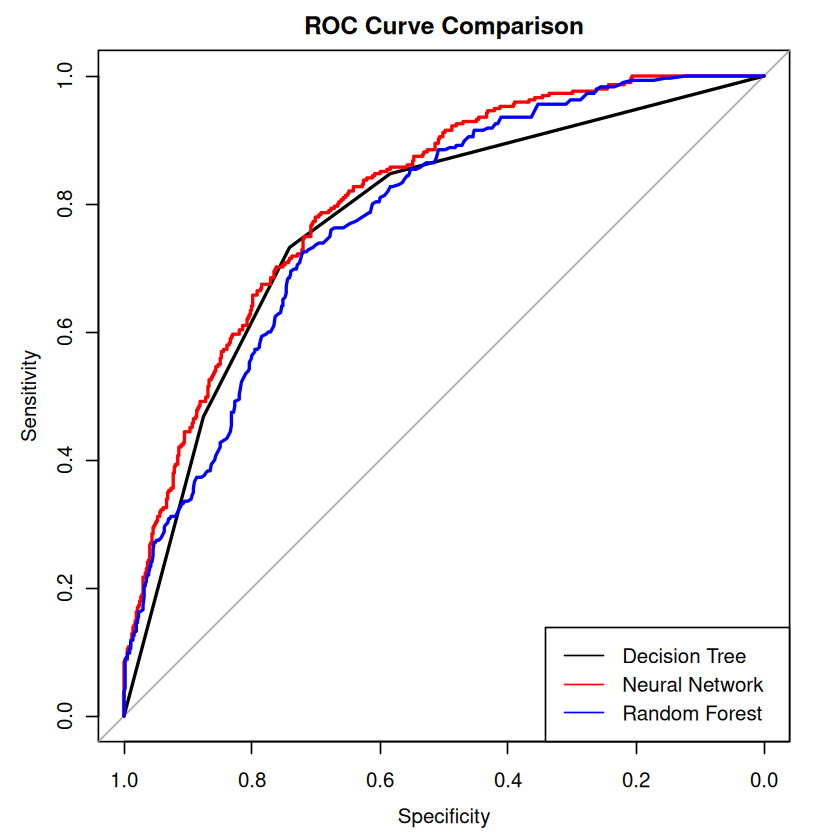

In [41]:
tree_roc <- roc(test_data$IsChurned, tree_pred_prob$Yes, levels = c("No", "Yes"))
nn_roc   <- roc(test_data$IsChurned, nn_pred_prob$Yes,   levels = c("No", "Yes"))
rf_roc   <- roc(test_data$IsChurned, rf_pred_prob$Yes,   levels = c("No", "Yes"))

plot(tree_roc, col = "black", main = "ROC Curve Comparison")
lines(nn_roc,  col = "red")
lines(rf_roc,  col = "blue")
legend("bottomright",
       legend = c("Decision Tree", "Neural Network", "Random Forest"),
       lty = 1, col = c("black", "red", "blue"))

### Variable importance

Variable importance is useful for interpreting which customer behaviours matter most for churn. Because **Recency**, **Frequency**, and **TotalSpent** were excluded from the classification models to avoid target leakage, the importance values below reflect the contribution of the remaining behavioural predictors such as order size, product diversity, customer activity span, and purchase intensity (for example, **OrdersPerMonth**).


In [42]:
varImp(tree_model)
varImp(nn_model)
varImp(rf_model)

rpart variable importance

                    Overall
ActiveMonths         100.00
TotalItems            93.64
DistinctProducts      87.86
AvgOrderValue         48.69
OrdersPerMonth        34.51
AvgItemsPerOrder      12.00
AvgProductsPerMonth    0.00

nnet variable importance

                    Overall
ActiveMonths        100.000
DistinctProducts     59.799
TotalItems           23.649
AvgOrderValue        20.370
AvgProductsPerMonth   8.134
OrdersPerMonth        4.634
AvgItemsPerOrder      0.000

rf variable importance

                    Overall
TotalItems           100.00
AvgOrderValue         90.49
DistinctProducts      75.19
AvgItemsPerOrder      69.76
AvgProductsPerMonth   48.26
ActiveMonths          40.36
OrdersPerMonth         0.00

### Classification Conclusion

Results summary for the classification models:

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Decision Tree (0.35) | 0.738 | 0.593 | 0.732 | 0.656 | 0.773 |
| Neural Network (default) | 0.747 | 0.679 | 0.488 | 0.568 | **0.810** |
| Neural Network (0.35) | 0.724 | 0.569 | **0.780** | 0.658 | 0.810 |
| Random Forest | 0.715 | 0.591 | 0.529 | 0.558 | 0.777 |

**Key findings:**

- The **Neural Network** achieved the highest AUC (0.810), making it the best model for overall discrimination and customer risk ranking.
- At the default 0.5 cutoff, the Neural Network is too conservative for churn operations because recall falls to 0.488.
- Lowering the Neural Network threshold to 0.35 increases recall to **0.780**, which makes it the strongest option when the business priority is to catch as many churners as possible.
- The **Decision Tree at 0.35** remains highly competitive with recall of 0.732 and offers the clearest interpretability for presentation and business explanation.
- **Random Forest** is a useful ensemble benchmark, but in this notebook it does not outperform the Neural Network on AUC or either recall-oriented option on churn capture.

Overall, the classification results support **H2**. The Neural Network provides the strongest ranking performance, while the threshold-tuned Neural Network and the Decision Tree provide the most practical operational options depending on whether the priority is maximum churn capture or interpretability.


## Time Series Analysis

Monthly revenue is aggregated from `df_clean` and analysed as a time series. The pipeline covers: smoothing (moving averages), stationarity testing (ADF), ACF/PACF inspection, model fitting (ETS, ARIMA, Seasonal Naive), holdout evaluation, and a 6-month forward forecast.

**Data constraint:** Only 13 monthly observations are available (Dec 2010 – Dec 2011). This limits forecasting reliability — all results should be treated as directional.


In [43]:
monthly_sales <- df_clean %>%
  mutate(Month = floor_date(invoice_date, unit = "month")) %>%
  group_by(Month) %>%
  summarise(
    MonthlyRevenue = sum(line_total),
    Transactions = n_distinct(invoice_no),
    Customers = n_distinct(customer_id),
    .groups = "drop"
  ) %>%
  arrange(Month)

monthly_sales

Month,MonthlyRevenue,Transactions,Customers
<dttm>,<dbl>,<int>,<int>
2010-12-01,572713.9,1400,885
2011-01-01,569445.0,987,741
2011-02-01,447137.3,997,758
2011-03-01,595500.8,1321,974
2011-04-01,469200.4,1149,856
2011-05-01,678594.6,1555,1056
2011-06-01,661213.7,1393,991
2011-07-01,600091.0,1331,949
2011-08-01,645343.9,1280,935


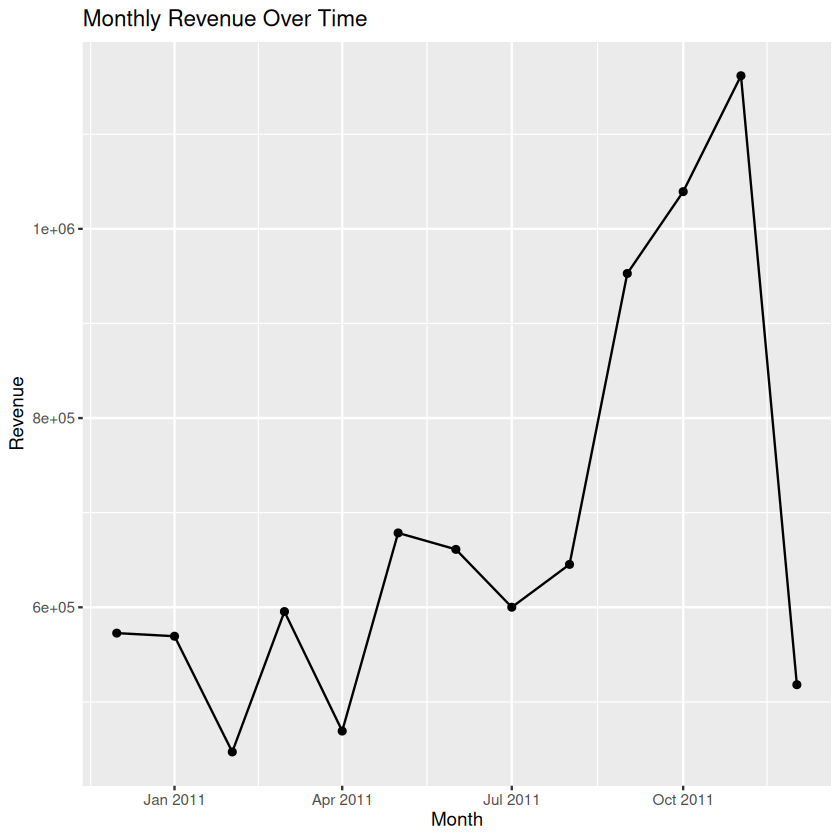

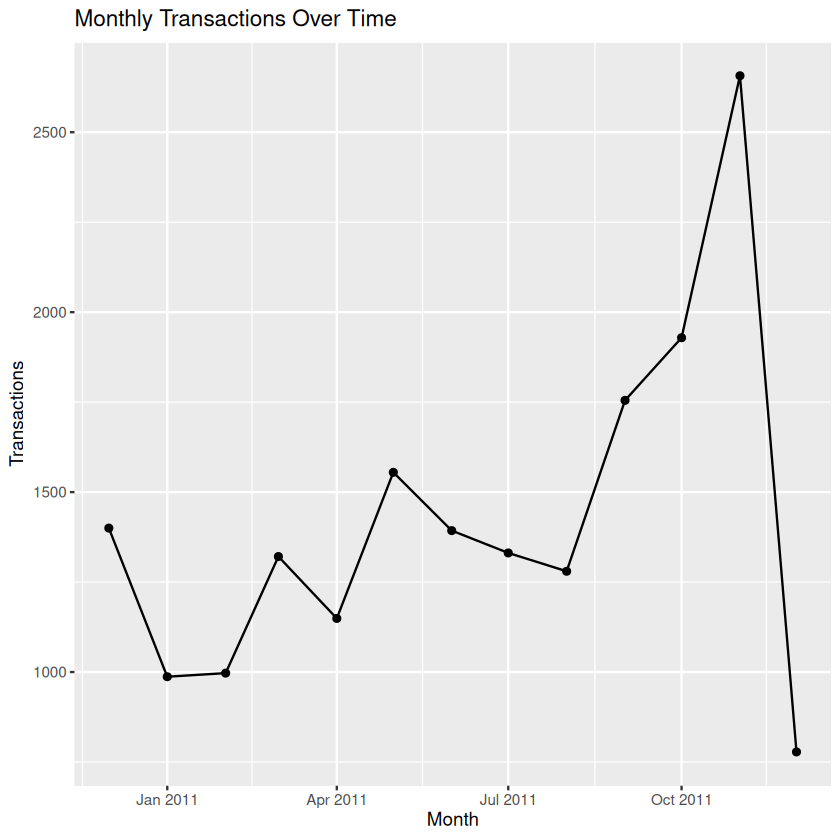

In [44]:
ggplot(monthly_sales, aes(x = Month, y = MonthlyRevenue)) +
  geom_line() +
  geom_point() +
  labs(title = "Monthly Revenue Over Time", x = "Month", y = "Revenue")

ggplot(monthly_sales, aes(x = Month, y = Transactions)) +
  geom_line() +
  geom_point() +
  labs(title = "Monthly Transactions Over Time", x = "Month", y = "Transactions")

### Convert to time-series object


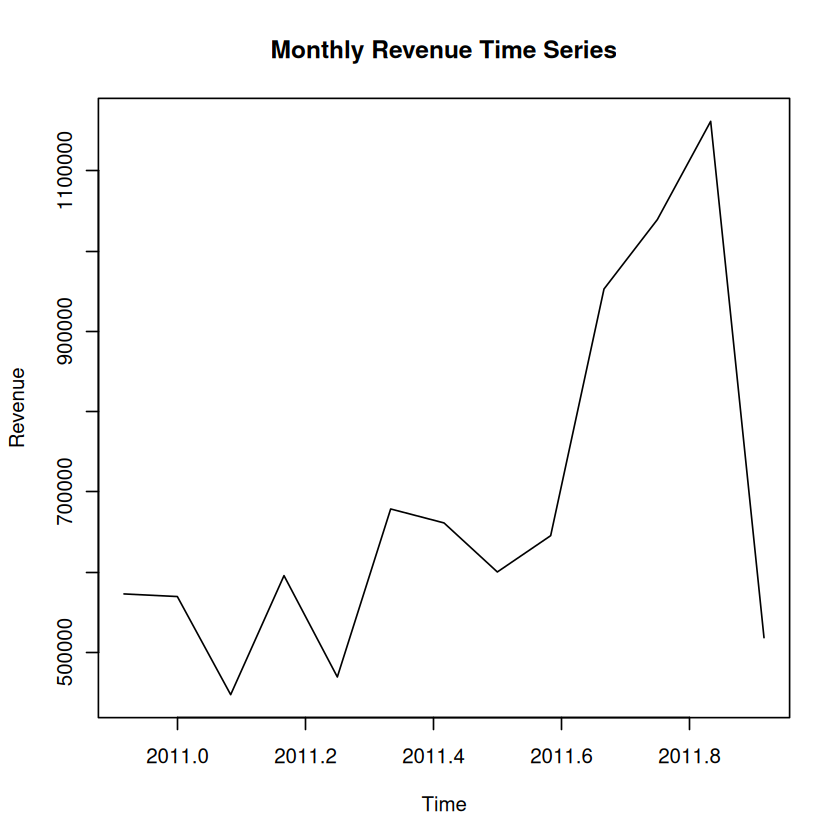

In [45]:
start_year <- year(min(monthly_sales$Month))
start_month <- month(min(monthly_sales$Month))

revenue_ts <- ts(monthly_sales$MonthlyRevenue, start = c(start_year, start_month), frequency = 12)
plot(revenue_ts, main = "Monthly Revenue Time Series", ylab = "Revenue", xlab = "Time")

### Smoothing and decomposition

Formal decomposition methods (`decompose()` and `stl()`) both require at least 2 full seasonal periods — 24 months for monthly data. Since this dataset spans only 13 months, decomposition is not applicable.

Instead, 3-month and 6-month centred moving averages are applied to smooth out short-term fluctuations and reveal the underlying revenue trend. The shorter MA reacts faster to changes, while the longer MA gives a broader view of the trend direction.


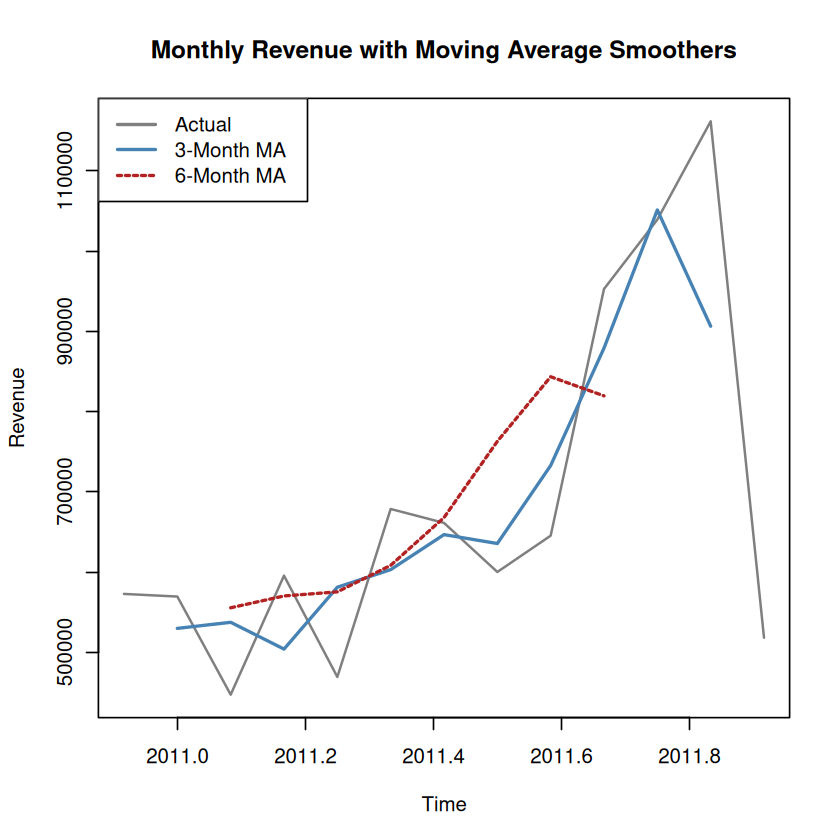

In [46]:
# NOTE: Both stl() and decompose() require at least 2 full seasonal periods (24 months).
# With only 13 months of data, formal decomposition is not feasible.
# Instead, we apply a 3-month and 6-month centred moving average to reveal the trend.

ma3 <- stats::filter(revenue_ts, rep(1/3, 3), sides = 2)
ma6 <- stats::filter(revenue_ts, rep(1/6, 6), sides = 2)

plot(revenue_ts,
     main = "Monthly Revenue with Moving Average Smoothers",
     ylab = "Revenue", xlab = "Time", col = "grey50", lwd = 1.5)
lines(ma3, col = "steelblue", lwd = 2)
lines(ma6, col = "firebrick", lwd = 2, lty = 2)
legend("topleft", legend = c("Actual", "3-Month MA", "6-Month MA"),
       col = c("grey50", "steelblue", "firebrick"),
       lwd = 2, lty = c(1, 1, 2))

### Stationarity checks and ACF/PACF

The ADF test (p = 0.2301) fails to reject the null hypothesis of a unit root — the series is **non-stationary**, consistent with the visible upward trend. `auto.arima()` handles differencing automatically. ACF and PACF plots provide additional context for autocorrelation structure.



	Augmented Dickey-Fuller Test

data:  revenue_ts
Dickey-Fuller = -2.8986, Lag order = 2, p-value = 0.2301
alternative hypothesis: stationary


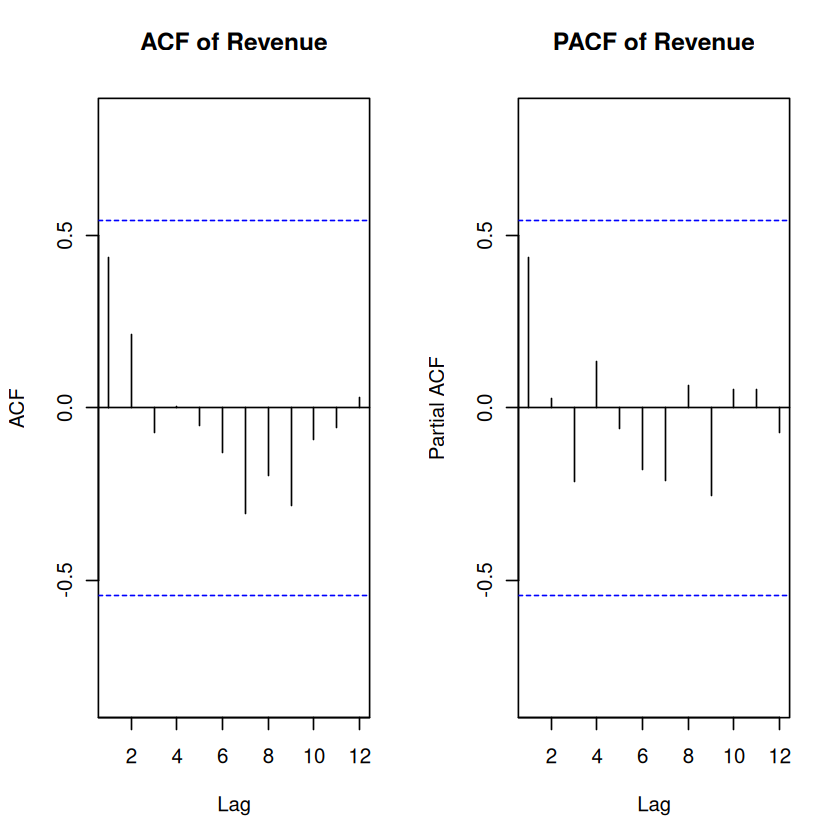

In [47]:
adf.test(revenue_ts)

par(mfrow = c(1, 2))
Acf(revenue_ts, main = "ACF of Revenue")
Pacf(revenue_ts, main = "PACF of Revenue")
par(mfrow = c(1, 1))

### Train-test split for forecasting

The final **3 months** are reserved as a holdout test set.  
Keeping a separate test period allows the forecasting models to be evaluated on unseen data and provides a more reliable assessment of predictive performance.


In [48]:
h <- 3
train_ts <- head(revenue_ts, length(revenue_ts) - h)
test_ts  <- tail(revenue_ts, h)

train_ts
test_ts

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2010,,,,,,,,,,,,572713.9
2011,569445.0,447137.3,595500.8,469200.4,678594.6,661213.7,600091.0,645343.9,952838.4,,,


,Oct,Nov,Dec
2011,1039318.8,1161817.4,518192.8


### Fit and compare forecasting models


In [49]:
ets_model <- ets(train_ts)
arima_model <- auto.arima(train_ts, seasonal = TRUE, stepwise = FALSE, approximation = FALSE)

if (length(train_ts) > frequency(train_ts)) {
  naive_model <- snaive(train_ts, h = h)
  naive_fc <- naive_model
} else {
  naive_model <- naive(train_ts, h = h)
  naive_fc <- naive_model
}

ets_fc <- forecast(ets_model, h = h)
arima_fc <- forecast(arima_model, h = h)

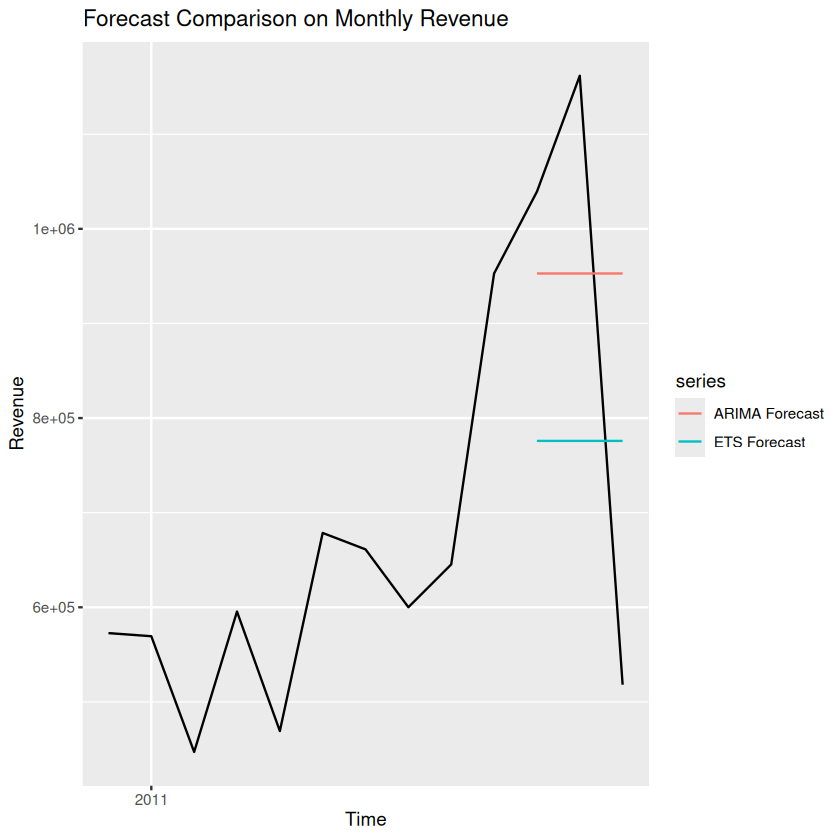

In [50]:
autoplot(revenue_ts) +
  autolayer(ets_fc$mean, series = "ETS Forecast") +
  autolayer(arima_fc$mean, series = "ARIMA Forecast") +
  labs(title = "Forecast Comparison on Monthly Revenue", y = "Revenue")

In [51]:
ets_acc <- forecast::accuracy(ets_fc, test_ts)
arima_acc <- forecast::accuracy(arima_fc, test_ts)
naive_acc <- forecast::accuracy(naive_fc, test_ts)

ets_acc
arima_acc
naive_acc

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,34416.86,131788.8,98641.25,2.027326,15.22718,NaN,-0.05420456,NA
Test set,130569.76,308088.5,302356.72,2.946720,36.09789,NaN,-0.27916615,0.7636839


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,38069.72,140505.6,104145.8,2.749477,16.28147,NaN,-0.3202145,NA
Test set,-46395.40,282882.7,243368.3,-19.189691,36.72844,NaN,-0.2791661,0.7498854


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,42236.05,148105.8,115653.9,3.043864,18.07941,NaN,-0.3272370,NA
Test set,-46395.40,282882.7,243368.3,-19.189691,36.72844,NaN,-0.2791661,0.7498854


In [52]:
forecast_comparison <- tibble(
  Model = c("Seasonal Naive", "ETS", "ARIMA"),
  RMSE = c(naive_acc[2, "RMSE"], ets_acc[2, "RMSE"], arima_acc[2, "RMSE"]),
  MAE  = c(naive_acc[2, "MAE"], ets_acc[2, "MAE"], arima_acc[2, "MAE"]),
  MAPE = c(naive_acc[2, "MAPE"], ets_acc[2, "MAPE"], arima_acc[2, "MAPE"])
)

forecast_comparison

Model,RMSE,MAE,MAPE
<chr>,<dbl>,<dbl>,<dbl>
Seasonal Naive,282882.7,243368.3,36.72844
ETS,308088.5,302356.7,36.09789
ARIMA,282882.7,243368.3,36.72844


### Diagnostics for the selected model

Residual diagnostics are run on the ARIMA model. ARIMA and Seasonal Naive produce identical RMSE/MAE/MAPE on the holdout — ARIMA is retained as the final model for the 6-month forecast, but it is not meaningfully superior to the naive benchmark on this short series.



	Ljung-Box test

data:  Residuals from ARIMA(0,1,0)
Q* = 1.84, df = 3, p-value = 0.6063

Model df: 0.   Total lags used: 3



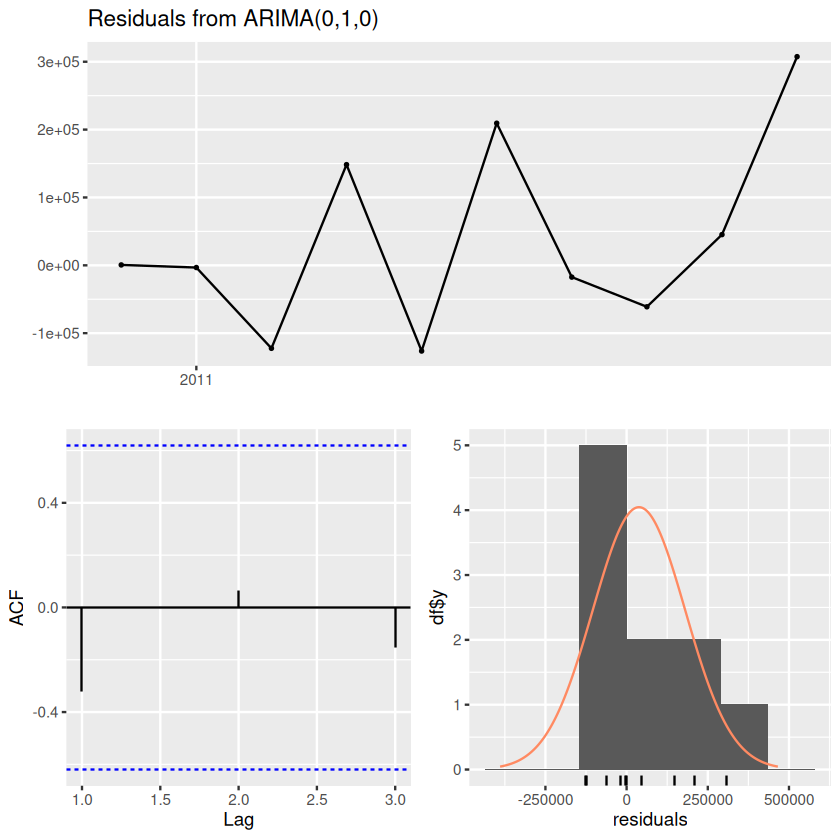

In [53]:
checkresiduals(arima_model)

         Point Forecast       Lo 80     Hi 80      Lo 95     Hi 95
Jan 2012       518192.8  223585.542  812800.0   67629.89  968755.7
Feb 2012       518192.8  101555.224  934830.4 -118999.38 1155385.0
Mar 2012       518192.8    7918.068 1028467.5 -262205.05 1298590.6
Apr 2012       518192.8  -71021.706 1107407.3 -382933.02 1419318.6
May 2012       518192.8 -140569.043 1176954.6 -489296.49 1525682.1
Jun 2012       518192.8 -203444.642 1239830.2 -585456.42 1621842.0

Month,ForecastRevenue,Lower80,Upper80,Lower95,Upper95
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2012-01-01,518192.8,223585.542,812800.0,67629.89,968755.7
2012-02-01,518192.8,101555.224,934830.4,-118999.38,1155385.0
2012-03-01,518192.8,7918.068,1028467.5,-262205.05,1298590.6
2012-04-01,518192.8,-71021.706,1107407.3,-382933.02,1419318.6
2012-05-01,518192.8,-140569.043,1176954.6,-489296.49,1525682.1
2012-06-01,518192.8,-203444.642,1239830.2,-585456.42,1621842.0


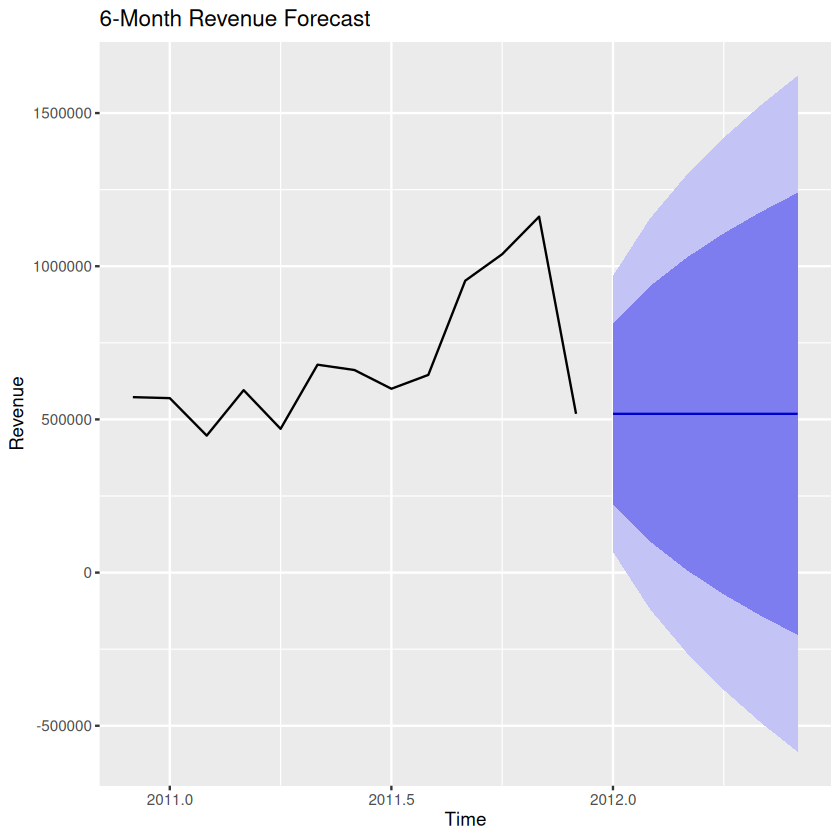

In [54]:
final_model <- auto.arima(revenue_ts, seasonal = TRUE, stepwise = FALSE, approximation = FALSE)
final_forecast <- forecast(final_model, h = 6)

forecast_dashboard <- tibble(
  Month = seq.Date(
    from = max(monthly_sales$Month) %m+% months(1),
    by = "month",
    length.out = 6
  ),
  ForecastRevenue = as.numeric(final_forecast$mean),
  Lower80 = as.numeric(final_forecast$lower[, 1]),
  Upper80 = as.numeric(final_forecast$upper[, 1]),
  Lower95 = as.numeric(final_forecast$lower[, 2]),
  Upper95 = as.numeric(final_forecast$upper[, 2])
)

autoplot(final_forecast) +
  labs(title = "6-Month Revenue Forecast", y = "Revenue")

final_forecast
forecast_dashboard

### Interpreting the Time-Series Patterns

- **Upward trend:** Revenue rises from ~£447K (Feb 2011) to a peak of ~£1.16M in November 2011.
- **November, not December, is the true peak:** December 2011 appears low (£518K) because the dataset ends on 9 December 2011. This is a data truncation artefact, not a genuine seasonal collapse.
- **Forecast model comparison:** ARIMA(0,1,0) and Seasonal Naive produce identical test-set RMSE (282,883) and MAE (243,368). ETS has slightly lower MAPE (36.1% vs 36.7%) but worse RMSE and MAE. No model is clearly superior on this short series.
- **Forecast reliability:** With only 13 monthly observations, all confidence intervals are wide. The 6-month forecast should be treated as directional only.


### Time Series Conclusion

**H3** is partially confirmed. Revenue rises strongly toward late 2011, which is consistent with pre-holiday demand, but the expected December peak cannot be evaluated properly because the dataset ends on 9 December 2011.

All three forecasting approaches (ARIMA, ETS, and Seasonal Naive) perform similarly on the 3-month holdout. ARIMA(0,1,0) is retained as the final forecasting model, but it should be treated as a directional baseline rather than a clearly superior model because it ties the naive benchmark on RMSE and MAE.

**Limitations:** With only 13 monthly observations, forecast confidence intervals are wide and the results should be treated as directional rather than precise. A minimum of 3 to 5 years of monthly data would be needed for reliable seasonal decomposition and stronger forecasting claims.

**Business recommendation:** Inventory and staffing decisions should be increased cautiously from October onward to capture the late-year demand surge, while avoiding overconfidence in the exact forecast levels because of the short time horizon.


## Summary Tables


In [55]:
# Summary table for report use
preprocess_summary <- tibble(
  Metric = c("Original Rows", "Cleaned Rows", "Unique Customers", "Date Start", "Date End"),
  Value = c(
    nrow(df),
    nrow(df_clean),
    n_distinct(df_clean$customer_id),
    as.character(min(df_clean$invoice_date, na.rm = TRUE)),
    as.character(max(df_clean$invoice_date, na.rm = TRUE))
  )
)

preprocess_summary
cluster_profile
results_compare
forecast_comparison

Metric,Value
<chr>,<chr>
Original Rows,541909
Cleaned Rows,397884
Unique Customers,4338
Date Start,2010-12-01 08:26:00
Date End,2011-12-09 12:50:00


Cluster,Customers,AvgRecency,AvgFrequency,AvgTotalSpent,AvgTotalItems,AvgOrderValue,AvgItemsPerOrder,AvgDistinctProducts
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1267,29.91170,9.892660,5731.6571,3311.5193,695.7653,424.52788,133.17285
2,1966,87.93456,2.195320,699.5595,417.5351,378.2229,232.03247,44.00509
3,1105,170.61761,1.522172,248.0221,136.8715,174.8621,95.50779,10.45068


Model,Accuracy,Kappa,Precision,Recall,F1,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Decision Tree (0.35 cutoff),0.7381776,0.4480851,0.5934066,0.7322034,0.6555387,0.7734295
Neural Network,0.7474048,0.3962492,0.6792453,0.4881356,0.5680473,0.8098317
Neural Network (0.35 threshold),0.7243368,0.4364204,0.5693069,0.7796610,0.6580830,0.8098317
Random Forest,0.7151096,0.3488794,0.5909091,0.5288136,0.5581395,0.7774861


Model,RMSE,MAE,MAPE
<chr>,<dbl>,<dbl>,<dbl>
Seasonal Naive,282882.7,243368.3,36.72844
ETS,308088.5,302356.7,36.09789
ARIMA,282882.7,243368.3,36.72844


## Notebook Summary

**Preprocessing:** 397,884 clean transactions retained from 541,909 original rows across 4,338 customers.

**Clustering:** K-means k = 3, silhouette = 0.246 (moderate separation). Cluster 1 (29.2%) represents loyal/high-value customers, Cluster 2 (45.3%) represents occasional customers, and Cluster 3 (25.5%) represents at-risk customers.

**Classification:** The default Neural Network achieved the highest AUC (0.810), so it is the strongest model for ranking customers by churn risk. After lowering the cutoff to 0.35, the Neural Network reached the highest recall (0.780), making it the strongest option when catching more churners is the main priority. The Decision Tree at 0.35 remained close behind on recall (0.732) and is the easiest model to explain operationally. Random Forest did not lead on either AUC or recall in this notebook.

**Time Series:** Revenue peaks in November 2011, while December is truncated. ARIMA(0,1,0) was selected as the final directional forecast model, but it performs similarly to Seasonal Naive and should be interpreted cautiously because the series contains only 13 monthly observations.


## Export Tables for Report and Dashboard

Exports clean summary tables to `dashboard_exports/` for use in the written report and Looker Studio dashboard.


In [56]:
# Create export folder
dir.create("dashboard_exports", showWarnings = FALSE)

# Build dashboard-specific views
monthly_sales_dashboard <- monthly_sales %>%
  dplyr::select(Month, MonthlyRevenue, Transactions, Customers)

customer_segment_dashboard <- customer_clusters %>%
  dplyr::select(
    customer_id,
    Cluster,
    IsChurned,
    TotalSpent,
    Frequency,
    Recency,
    AvgOrderValue,
    OrdersPerMonth,
    LastPurchaseDate
  )

# Export individual CSVs
write.csv(preprocess_summary,          "dashboard_exports/preprocess_summary.csv",          row.names = FALSE)
write.csv(cluster_profile,             "dashboard_exports/cluster_profile.csv",             row.names = FALSE)
write.csv(results_compare,             "dashboard_exports/model_results_compare.csv",       row.names = FALSE)
write.csv(forecast_comparison,         "dashboard_exports/forecast_comparison.csv",         row.names = FALSE)
write.csv(forecast_dashboard,          "dashboard_exports/forecast_dashboard.csv",          row.names = FALSE)
write.csv(monthly_sales_dashboard,     "dashboard_exports/monthly_sales_dashboard.csv",     row.names = FALSE)
write.csv(customer_segment_dashboard,  "dashboard_exports/customer_segment_dashboard.csv",  row.names = FALSE)

cat("CSV export complete. Files written to dashboard_exports/\n")

CSV export complete. Files written to dashboard_exports/
